In [33]:
# Import necessary libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sksurv.ensemble import RandomSurvivalForest

from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import train_test_split


In [34]:
import gc

gc.collect()

0

In [35]:
# Importing the dataset
dtafile = "file path"

master_immuno =pd.read_parquet(dtafile)

#### Feature Selection

In [36]:
# --- Select key columns ---
col_names = [
    'i_thy','i_ale','i_bas','i_bas_thy','c_ci_mmf','c_ci_mmf_steroids','AGE','male_pt','white_pt','black_pt','hisp_pt','asian_pt','retx',
    'DAYSWAIT_CHRON','ON_DIALYSIS','CREAT_TRR','END_CPRA','BMI_CALC','diab', 'AGE_DON','male_don','white_don','black_don','hisp_don',
    'asian_don','CREAT_DON','diab_don','hyper_don','BMI_DON_CALC','KDPI','dcd','ECD_DONOR','COLD_ISCH_KI','local','regional','national', 
    'DON_TY',                      # donor type
    'GTIME_KI','PSTATUS',          # graft failure
    'PTIME','PX_STAT'              # patient death
]

In [37]:
data = master_immuno.loc[:, col_names].copy()
data.head()

,i_thy,i_ale,i_bas,i_bas_thy,c_ci_mmf,c_ci_mmf_steroids,AGE,male_pt,white_pt,black_pt,...,ECD_DONOR,COLD_ISCH_KI,local,regional,national,DON_TY,GTIME_KI,PSTATUS,PTIME,PX_STAT
0,1,0,0,0,0,0,28,0,0,0,...,0.0,NaN,1,0,0,C,867.0,1,6407.0,A
1,0,0,1,0,0,1,44,0,0,1,...,0.0,NaN,0,0,1,C,6334.0,0,6334.0,A
2,1,0,0,0,0,1,39,1,1,0,...,0.0,3.0,1,0,0,C,1069.0,0,1069.0,R
3,0,0,1,0,0,1,39,1,0,0,...,0.0,6.0,0,0,1,C,1999.0,1,1999.0,D
4,0,0,1,0,0,0,34,0,1,0,...,0.0,30.0,1,0,0,C,24.0,0,24.0,L


**Focus on deceased donors only, subset on variables that are only defined for deceased donors**

**data['DON_TY'].value-counts()**

Based on the value counts:
- C = Cadaveric/Deceased (229,285)
- L = Living (114,502) 
- F = Other (4)

In [38]:
# --- Keep deceased-donor kidney transplants ---
df = data[data["DON_TY"] == "C"].copy()

# --- Clean blanks and missing ---
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

In [39]:
# Convert key binary / categorical values
df['ON_DIALYSIS'] = df['ON_DIALYSIS'].map({'Y':1, 'N':0}).astype('Int8')
df['PX_STAT'] = df['PX_STAT'].map({'D':1, 'A':0, 'L':0, 'R':0}).astype('Int8')
df["PSTATUS"] = df["PSTATUS"].map({1:1, 0:0})

In [40]:
# Basic sanity check
print("Value counts after mapping:")
print("ON_DIALYSIS:", df["ON_DIALYSIS"].value_counts(dropna=False).to_dict())
print("PSTATUS:",     df["PSTATUS"].value_counts(dropna=False).to_dict())
print("PX_STAT:",     df["PX_STAT"].value_counts(dropna=False).to_dict())
df.drop(columns=["DON_TY"], inplace=True)
print("DON_TY in df:", "DON_TY" in df.columns)

Value counts after mapping:
ON_DIALYSIS: {np.int8(1): 190339, np.int8(0): 38931, <NA>: 15}
PSTATUS: {0: 173722, 1: 55563}
PX_STAT: {np.int8(0): 185377, np.int8(1): 43907, <NA>: 1}
DON_TY in df: False


#### Checking the missing data

In [41]:
# finding the sum of total null values in the dataset
pd.set_option('display.max_rows', None)
missing_df = (
    df.isnull().sum()
    .reset_index()
    .rename(columns={'index':'Feature', 0:'Missing_Values'})
)
missing_df['Missing %'] = (missing_df['Missing_Values'] / data.shape[0]) * 100

pd.set_option('display.max_rows', None)
print(missing_df)


              Feature  Missing_Values  Missing %
0               i_thy               0   0.000000
1               i_ale               0   0.000000
2               i_bas               0   0.000000
3           i_bas_thy               0   0.000000
4            c_ci_mmf               0   0.000000
5   c_ci_mmf_steroids               0   0.000000
6                 AGE               0   0.000000
7             male_pt               0   0.000000
8            white_pt               0   0.000000
9            black_pt               0   0.000000
10            hisp_pt               0   0.000000
11           asian_pt               0   0.000000
12               retx               0   0.000000
13     DAYSWAIT_CHRON               1   0.000291
14        ON_DIALYSIS              15   0.004363
15          CREAT_TRR            2479   0.721078
16           END_CPRA           50815  14.780783
17           BMI_CALC             430   0.125076
18               diab               0   0.000000
19            AGE_DO

#### Handling Missing Data

In [42]:
# ---- 1) Numeric variables (median impute) ----
num_impute = ['DAYSWAIT_CHRON','CREAT_TRR','BMI_CALC','BMI_DON_CALC','CREAT_DON','KDPI']
for col in num_impute:
    df[col] = df[col].astype(float)
    df[col] = df[col].fillna(df[col].median())

# ---- 2) Binary/categorical (mode impute) ----
cat_impute = ['ON_DIALYSIS','diab','diab_don','hyper_don']
for col in cat_impute:
    df[col] = df[col].fillna(df[col].mode()[0])

# ---- 3) Sensitization (cPRA): flag & neutral-value impute ----
df['END_CPRA_missing'] = df['END_CPRA'].isna().astype(int)
df['END_CPRA'] = df['END_CPRA'].fillna(0)   # 0 = no sensitization detectable

# ---- 4) Cold ischemia time (CIT): flag & median impute ----
df['COLD_ISCH_KI_missing'] = df['COLD_ISCH_KI'].isna().astype(int)
df['COLD_ISCH_KI'] = df['COLD_ISCH_KI'].fillna(df['COLD_ISCH_KI'].median())


In [43]:
#  Drop any residual missing records (GTIME/PTIME rarely missing)
df.dropna(axis=0, inplace=True)
print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


In [44]:
df.shape

(229283, 42)

In [45]:
# datatypes of each feature
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229283 entries, 0 to 343789
Data columns (total 42 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   i_thy                 229283 non-null  int64  
 1   i_ale                 229283 non-null  int8   
 2   i_bas                 229283 non-null  int64  
 3   i_bas_thy             229283 non-null  int64  
 4   c_ci_mmf              229283 non-null  int8   
 5   c_ci_mmf_steroids     229283 non-null  int8   
 6   AGE                   229283 non-null  int8   
 7   male_pt               229283 non-null  int8   
 8   white_pt              229283 non-null  int8   
 9   black_pt              229283 non-null  int8   
 10  hisp_pt               229283 non-null  int8   
 11  asian_pt              229283 non-null  int8   
 12  retx                  229283 non-null  int8   
 13  DAYSWAIT_CHRON        229283 non-null  float64
 14  ON_DIALYSIS           229283 non-null  Int8   
 15  CREAT

In [46]:
# Binary indicator columns -> category
binary_cols = [
    'i_thy','i_ale','i_bas','i_bas_thy','c_ci_mmf','c_ci_mmf_steroids','ECD_DONOR',
    'male_pt','white_pt','black_pt','hisp_pt','asian_pt','retx','hyper_don',
    'male_don','white_don','black_don','hisp_don','asian_don','diab','diab_don',
    'dcd','local','regional','national','PSTATUS','PX_STAT'
]
df[binary_cols] = df[binary_cols].astype('category')

# Recipient age → int16
df['AGE'] = df['AGE'].astype('int16')

# Continuous recipient variables → float32
cont_cols = ['DAYSWAIT_CHRON','CREAT_TRR','END_CPRA','BMI_CALC']
df[cont_cols] = df[cont_cols].astype('float32')

# Donor continuous variables → float32
donor_cont_cols = ['AGE_DON','CREAT_DON','BMI_DON_CALC','KDPI','COLD_ISCH_KI']
df[donor_cont_cols] = df[donor_cont_cols].astype('float32')

# Survival outcome vars
df['GTIME_KI'] = df['GTIME_KI'].astype('int32')
df['PTIME']    = df['PTIME'].astype('int32')

#### Exploring the Target Feature
- Values like 365, 366, 364, etc. suggest annual follow-up recording (1 year, 2 years, etc.) in days.
- Distribution has a strong spike at 1-year multiples (common in registry follow-ups).
- Longest follow-ups: ~ 7582 days (~20.8 years) → plausible for kidney transplant cohorts.
- Units = days (if you plan to present survival curves, you may want to divide by 365.25 to report in years).
- PX_STAT was string-coded, it contained 'A', 'D', 'L', 'R'. The Correct logic is 1 = death, 0 = alive/lost/retransplanted

In [47]:
# --- Define survival outcomes ---
df["event_graft"] = df["PSTATUS"].astype("Int8")
df["time_graft"]  = df["GTIME_KI"].astype("int32")

df["event_death"] = df["PX_STAT"].astype("Int8")
df["time_death"]  = df["PTIME"].astype("int32")


##### Handling Zero/Negative Survival Times 
- Mathematical Impossibility: Survival analysis assumes T > 0
- Model Crashes: Cox models and Kaplan-Meier will fail or produce erroneous results
- Clinical Nonsense: A transplant can't fail at time zero
- Statistical tests will be invalid
- Data Quality Flag: Often indicates data entry errors or special cases

What Zero/Negative Times Might Indicate:
- Data Entry Errors: True time unknown, entered as zero
- Perioperative Deaths: Patients who died during transplant surgery
- Primary Non-function: Grafts that never worked
- Follow-up Issues: Lost to follow-up immediately

We excluded patients with zero or negative follow-up times (n=X) as these represent mathematical impossibilities in survival analysis and may indicate data quality issues or perioperative events requiring separate consideration.

In [48]:
# Check how many would be dropped
bad_mask = (df["time_graft"] <= 0) | (df["time_death"] <= 0)
print("Rows with non-positive survival time:", int(bad_mask.sum()))

# Filter to valid survival rows
df = df[(df["time_graft"] > 0) & (df["time_death"] > 0)].copy()

print("Final dataset shape:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))

Rows with non-positive survival time: 428
Final dataset shape: (228855, 46)
Remaining missing values: 0


### Descriptive Statistics

In [49]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# -----------------------------------
# CONFIGURATION
# -----------------------------------
df_desc = df.copy()

# Convert follow-up time to years for interpretability
df_desc["time_graft_years"] = df_desc["GTIME_KI"] / 365.25
df_desc["time_death_years"] = df_desc["PTIME"] / 365.25

# Event columns (ensure clean 0/1 int coding)
event_map = {True: 1, False: 0, "1": 1, "0": 0, 1: 1, 0: 0}
df_desc["PSTATUS"] = df_desc["PSTATUS"].map(event_map).astype("Int8")
df_desc["PX_STAT"] = df_desc["PX_STAT"].map(event_map).astype("Int8")

# Drop invalid/zero follow-up
df_desc = df_desc[df_desc["time_graft_years"] > 0]
df_desc = df_desc[df_desc["time_death_years"] > 0]

print("Event coding check:")
print(df_desc[["PSTATUS","PX_STAT"]].apply(pd.Series.value_counts).fillna(0))

Event coding check:
   PSTATUS  PX_STAT
0   173509   185083
1    55346    43772


#### Overall Graft and Patient Survival — Deceased Donor Cohort
Kaplan–Meier (KM) survival analysis for the overall deceased-donor kidney transplant cohort.


[Overall Graft Survival] N=228,855 | events=55,346 | censored=173,509


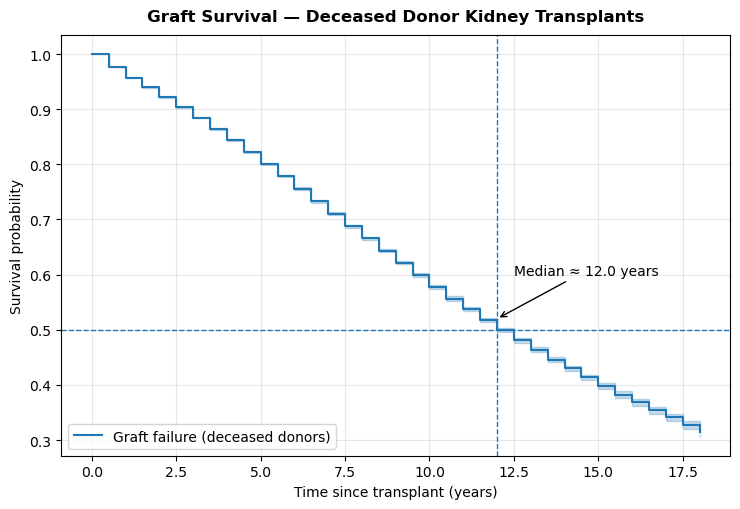


KM summary (graft, head):
          Graft failure (deceased donors)
timeline                                 
0.0                              1.000000
0.5                              0.976399
1.0                              0.957311
1.5                              0.939435
2.0                              0.921490
Median graft survival (years): 12.00


In [50]:
# -----------------------------------
# OVERALL GRAFT SURVIVAL
# -----------------------------------
n_total  = len(df_desc)
n_graft_events = int(df_desc["PSTATUS"].sum())
n_graft_cens   = n_total - n_graft_events
print(f"\n[Overall Graft Survival] N={n_total:,} | events={n_graft_events:,} | censored={n_graft_cens:,}")

tmax = float(np.nanpercentile(df_desc["time_graft_years"], 99.5))
timeline = np.arange(0, np.ceil(tmax * 2) / 2 + 1e-9, 0.5)

kmf_graft = KaplanMeierFitter()
kmf_graft.fit(df_desc["time_graft_years"], event_observed=df_desc["PSTATUS"],
              label="Graft failure (deceased donors)", timeline=timeline)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
kmf_graft.plot_survival_function(ax=ax, ci_show=True)
ax.set_title("Graft Survival — Deceased Donor Kidney Transplants", pad=10, weight="bold")
ax.set_xlabel("Time since transplant (years)")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)

med_graft = kmf_graft.median_survival_time_
if np.isfinite(med_graft):
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.axvline(med_graft, linestyle="--", linewidth=1)
    ax.annotate(f"Median ≈ {med_graft:.1f} years", xy=(med_graft, 0.52), xytext=(med_graft+0.5, 0.6),
                arrowprops=dict(arrowstyle="->", lw=1))
plt.tight_layout()
plt.show()

print("\nKM summary (graft, head):")
print(kmf_graft.survival_function_.head())
print(f"Median graft survival (years): {med_graft:.2f}" if np.isfinite(med_graft) else "Median graft survival: Not reached")



[Overall Patient Survival] N=228,855 | deaths=43,772 | censored=185,083


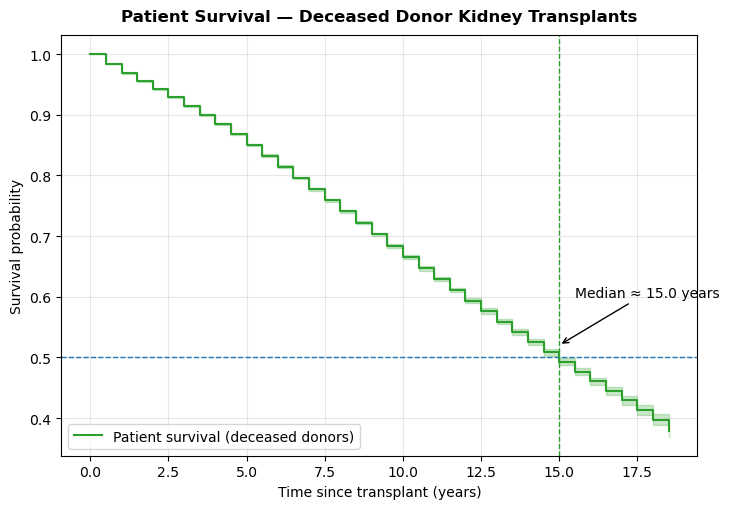


KM summary (death, head):
          Patient survival (deceased donors)
timeline                                    
0.0                                 1.000000
0.5                                 0.983441
1.0                                 0.968478
1.5                                 0.955173
2.0                                 0.941844
Median patient survival (years): 15.00


In [51]:
# -----------------------------------
# OVERALL PATIENT SURVIVAL
# -----------------------------------
n_death_events = int(df_desc["PX_STAT"].sum())
n_death_cens   = n_total - n_death_events
print(f"\n[Overall Patient Survival] N={n_total:,} | deaths={n_death_events:,} | censored={n_death_cens:,}")

tmax_d = float(np.nanpercentile(df_desc["time_death_years"], 99.5))
timeline_d = np.arange(0, np.ceil(tmax_d * 2) / 2 + 1e-9, 0.5)

kmf_death = KaplanMeierFitter()
kmf_death.fit(df_desc["time_death_years"], event_observed=df_desc["PX_STAT"],
              label="Patient survival (deceased donors)", timeline=timeline_d)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
kmf_death.plot_survival_function(ax=ax, ci_show=True, color="tab:green")
ax.set_title("Patient Survival — Deceased Donor Kidney Transplants", pad=10, weight="bold")
ax.set_xlabel("Time since transplant (years)")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)

med_death = kmf_death.median_survival_time_
if np.isfinite(med_death):
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.axvline(med_death, linestyle="--", linewidth=1, color="tab:green")
    ax.annotate(f"Median ≈ {med_death:.1f} years", xy=(med_death, 0.52), xytext=(med_death+0.5, 0.6),
                arrowprops=dict(arrowstyle="->", lw=1))
plt.tight_layout()
plt.show()

print("\nKM summary (death, head):")
print(kmf_death.survival_function_.head())
print(f"Median patient survival (years): {med_death:.2f}" if np.isfinite(med_death) else "Median patient survival: Not reached")

#### Risk Table Extraction for Graft and Patient Survival
1. Converts KM event tables from lifelines into human-readable form.
2. Interpolates at-risk counts at specified yearly intervals.
3. Produces both cumulative and interval counts for events and censoring.
4. Normalizes time units to years (instead of days), matching your plots.
5. Enables side-by-side table reporting in publication (e.g., “Table 1. Number at risk and events over time”).

**Interpretation**
- These tables can be:
- Reported alongside your KM figures,
- Used to validate total event counts (should match KM summaries),
- Or merged with your plotting data to annotate number at risk under survival curves (like ggsurvplot does in R).

In [20]:
# Define a uniform time grid (years)
tick_step = 2.0  # interval in years (Change to 1.0 or 5.0 for denser/sparser intervals)
t_max = float(np.nanmax(df_desc["time_graft_years"]))
times_years = np.arange(0, np.ceil(t_max / tick_step) * tick_step + 1e-9, tick_step)
grid_index = pd.Index(times_years, name="time_years")

# -------------------------------------------------------------
# GRAFT SURVIVAL RISK TABLE (Fixed)
# -------------------------------------------------------------
evt_full_graft = kmf_graft.event_table.copy()
n0_graft = int(evt_full_graft.iloc[0]["at_risk"])

evt_graft = evt_full_graft.iloc[1:].copy()
evt_graft.index.name = "time_years"

at_risk_graft = (
    evt_graft["at_risk"]
    .reindex(grid_index, method="ffill")
    .fillna(n0_graft)
    .round()
    .astype(int)
)

cum_events_graft = evt_graft["observed"].cumsum()
cum_cens_graft   = evt_graft["censored"].cumsum()

cum_events_graft_grid = cum_events_graft.reindex(grid_index, method="ffill").fillna(0)
cum_cens_graft_grid   = cum_cens_graft.reindex(grid_index, method="ffill").fillna(0)

events_interval_graft   = cum_events_graft_grid.diff().fillna(cum_events_graft_grid.iloc[0]).round().astype(int)
censored_interval_graft = cum_cens_graft_grid.diff().fillna(cum_cens_graft_grid.iloc[0]).round().astype(int)

risk_table_graft = pd.DataFrame({
    "time_years": times_years,
    "at_risk": at_risk_graft.values,
    "events": events_interval_graft.values,
    "censored": censored_interval_graft.values
})

print("GRAFT SURVIVAL RISK TABLE:")
risk_table_graft.head(12)

GRAFT SURVIVAL RISK TABLE:


,time_years,at_risk,events,censored
0,0.0,228855,0,0
1,2.0,166868,16350,46160
2,4.0,115555,12212,38931
3,6.0,75041,10481,29943
4,8.0,40348,7292,27344
5,10.0,20935,4158,15119
6,12.0,11905,2378,6622
7,14.0,6236,1350,4305
8,16.0,2845,694,2698
9,18.0,1078,306,1444


In [21]:
# -------------------------------------------------------------
# PATIENT SURVIVAL RISK TABLE (Fixed)
# -------------------------------------------------------------
evt_full_patient = kmf_death.event_table.copy()
n0_patient = int(evt_full_patient.iloc[0]["at_risk"])

evt_patient = evt_full_patient.iloc[1:].copy()
evt_patient.index.name = "time_years"

at_risk_patient = (
    evt_patient["at_risk"]
    .reindex(grid_index, method="ffill")
    .fillna(n0_patient)
    .round()
    .astype(int)
)

cum_events_patient = evt_patient["observed"].cumsum()
cum_cens_patient   = evt_patient["censored"].cumsum()

cum_events_patient_grid = cum_events_patient.reindex(grid_index, method="ffill").fillna(0)
cum_cens_patient_grid   = cum_cens_patient.reindex(grid_index, method="ffill").fillna(0)

events_interval_patient   = cum_events_patient_grid.diff().fillna(cum_events_patient_grid.iloc[0]).round().astype(int)
censored_interval_patient = cum_cens_patient_grid.diff().fillna(cum_cens_patient_grid.iloc[0]).round().astype(int)

risk_table_patient = pd.DataFrame({
    "time_years": times_years,
    "at_risk": at_risk_patient.values,
    "events": events_interval_patient.values,
    "censored": censored_interval_patient.values
})

print("\n PATIENT SURVIVAL RISK TABLE (first 10 rows):")
risk_table_patient.head(12)


 PATIENT SURVIVAL RISK TABLE (first 10 rows):


,time_years,at_risk,events,censored
0,0.0,228855,0,0
1,2.0,172192,12176,45010
2,4.0,122543,9231,40251
3,6.0,81394,8334,32731
4,8.0,45020,5988,30329
5,10.0,23944,3558,17379
6,12.0,13644,2128,8142
7,14.0,7124,1247,5258
8,16.0,3191,667,3265
9,18.0,1183,312,1675


In [22]:
# -------------------------------------------------------------
# Optional: Save to CSV
# -------------------------------------------------------------
# risk_table_graft.to_csv("risk_table_graft.csv", index=False)
# risk_table_patient.to_csv("risk_table_patient.csv", index=False)

In [23]:
def km_summary_at_times_from_fitted(kmf, times, label=None, round_to_grid=0.5):
    """
    Build a publication-ready KM summary using the SAME fitted KM (and its timeline).
    Also returns exact and grid-rounded median survival for consistency with plots.
    """
    times = np.asarray(times, dtype=float)

    # survival + CI tables are already aligned to the kmf.timeline (if you passed one on fit)
    sf = kmf.survival_function_.copy()          # column: label or 'KM_estimate'
    ci = kmf.confidence_interval_.copy()        # two columns (lower/upper)
    sf_col = sf.columns[0]
    ci_lower_col, ci_upper_col = list(ci.columns)[:2]

    # event table for "N at risk"; includes -inf at row 0
    evt = kmf.event_table.copy()
    n0 = int(evt.iloc[0]["at_risk"])
    evt_pos = evt.iloc[1:].copy()               # drop -inf row
    evt_pos.index.name = "time"

    # Generic step lookups against the fitted tables
    def step_lookup(df, col, t):
        idx = df.index.values
        i = np.searchsorted(idx, t, side="right") - 1
        if i < 0:
            return 1.0
        return float(df.iloc[i][col])

    def step_lookup_ci(df, lower_col, upper_col, t):
        idx = df.index.values
        i = np.searchsorted(idx, t, side="right") - 1
        if i < 0:
            return (1.0, 1.0)
        row = df.iloc[i]
        return float(row[lower_col]), float(row[upper_col])

    def step_lookup_atrisk(evt_pos_df, t):
        idx = evt_pos_df.index.values
        i = np.searchsorted(idx, t, side="right") - 1
        if i < 0:
            return n0
        return int(evt_pos_df.iloc[i]["at_risk"])

    rows = []
    for t in times:
        s = step_lookup(sf, sf_col, t)
        lo, hi = step_lookup_ci(ci, ci_lower_col, ci_upper_col, t)
        n_at_risk = step_lookup_atrisk(evt_pos, t)
        rows.append({
            "Time (years)": float(t),
            "N at risk": n_at_risk,
            "Survival": round(s, 3),
            "Lower 95%": round(lo, 3),
            "Upper 95%": round(hi, 3),
            "Label": label if label is not None else sf_col
        })
    table = pd.DataFrame(rows)[["Time (years)","N at risk","Survival","Lower 95%","Upper 95%","Label"]]

    # Medians: exact and grid-rounded (so figures & tables match visually)
    med_exact = kmf.median_survival_time_
    med_grid  = None
    if np.isfinite(med_exact):
        if round_to_grid is not None and round_to_grid > 0:
            med_grid = round_to_grid * round(float(med_exact) / round_to_grid)
        else:
            med_grid = float(med_exact)

    return table, (float(med_exact) if np.isfinite(med_exact) else np.nan), med_grid

# ======== USAGE (GRAFT) ========
query_years = [1, 3, 5, 10]
tbl_graft, med_graft_exact, med_graft_grid = km_summary_at_times_from_fitted(
    kmf_graft, query_years, label="Graft survival", round_to_grid=0.5
)
print("\nKM summary — Graft (1/3/5/10 years):")
print(tbl_graft.to_string(index=False))
print(f"\nMedian graft survival — exact: {med_graft_exact:.2f} years")
print(f"Median graft survival — rounded to 0.5y grid: {med_graft_grid:.2f} years")

# ======== USAGE (PATIENT) ========
tbl_death, med_death_exact, med_death_grid = km_summary_at_times_from_fitted(
    kmf_death, query_years, label="Patient survival", round_to_grid=0.5
)
print("\nKM summary — Patient (1/3/5/10 years):")
print(tbl_death.to_string(index=False))
print(f"\nMedian patient survival — exact: {med_death_exact:.2f} years")
print(f"Median patient survival — rounded to 0.5y grid: {med_death_grid:.2f} years")



KM summary — Graft (1/3/5/10 years):
 Time (years)  N at risk  Survival  Lower 95%  Upper 95%          Label
          1.0     197478     0.957      0.956      0.958 Graft survival
          3.0     140017     0.885      0.883      0.886 Graft survival
          5.0      94936     0.801      0.799      0.803 Graft survival
         10.0      20935     0.578      0.574      0.581 Graft survival

Median graft survival — exact: 12.00 years
Median graft survival — rounded to 0.5y grid: 12.00 years

KM summary — Patient (1/3/5/10 years):
 Time (years)  N at risk  Survival  Lower 95%  Upper 95%            Label
          1.0     201096     0.968      0.968      0.969 Patient survival
          3.0     146458     0.914      0.913      0.916 Patient survival
          5.0     101904     0.851      0.849      0.852 Patient survival
         10.0      23944     0.665      0.662      0.669 Patient survival

Median patient survival — exact: 15.00 years
Median patient survival — rounded to 0.5y gr

#### Kaplan–Meier Curves (Univariate exploration)
Get a sense of the outcome and stratify by key predictors before running Cox. Stratified by categorical variable (e.g., diabetes or ECD donor)

**Unadjusted KM + Log-rank (Binary Group) for GRAFT & PATIENT**

In [24]:
# ============================================================
# Naming consistent with earlier steps: df, df_desc, time_*_years
# ============================================================

# ------------------------------------------------------------
# 0) Prepare analysis copy & ensure time/event columns are clean
# ------------------------------------------------------------
df_desc = df.copy()

# Time to years (readability)
df_desc["time_graft_years"] = df_desc["GTIME_KI"] / 365.25
df_desc["time_death_years"] = df_desc["PTIME"]    / 365.25

# --- PSTATUS: ensure strict 0/1 ints
df_desc["PSTATUS"] = (
    df_desc["PSTATUS"]
      .replace({True:1, False:0, "1":1, "0":0})
      .astype("Int8")
)

# --- PX_STAT: robust mapping for UNOS codes (A/D/L/R) or existing 0/1
_px_map = {'D':1, 'A':0, 'L':0, 'R':0, True:1, False:0, "1":1, "0":0}
df_desc["PX_STAT"] = (
    df_desc["PX_STAT"]
      .replace(_px_map)
      .astype("Int8")
)

# Drop invalid/zero follow-up time rows per outcome when used
def _drop_invalid(df_in, time_col):
    out = df_in[np.isfinite(df_in[time_col]) & (df_in[time_col] > 0)].copy()
    return out

In [26]:
# ------------------------------------------------------------
# Helper: Risk table from a fitted KMF on a shared grid of YEARS
# ------------------------------------------------------------
def risk_table_from_kmf(kmf_fitted: KaplanMeierFitter, grid_years: np.ndarray) -> pd.DataFrame:
    """
    Returns DataFrame with: time_years, at_risk (just prior), events, censored
    Counts are aligned to the provided 'grid_years' (years).
    Assumes the KMF was fit using YEARS as the time unit.
    """
    evt_full = kmf_fitted.event_table.copy()      # includes '-inf' row
    n0 = int(evt_full.iloc[0]["at_risk"])
    evt = evt_full.iloc[1:].copy()                # drop '-inf'
    evt.index.name = "time_years"

    grid_index = pd.Index(grid_years, name="time_years")

    at_risk = (
        evt["at_risk"]
        .reindex(grid_index, method="ffill")
        .fillna(n0)
        .round()
        .astype(int)
    )
    cum_events = evt["observed"].cumsum()
    cum_cens   = evt["censored"].cumsum()

    cum_events_grid = cum_events.reindex(grid_index, method="ffill").fillna(0.0)
    cum_cens_grid   = cum_cens.reindex(grid_index, method="ffill").fillna(0.0)

    events_int   = cum_events_grid.diff().fillna(cum_events_grid.iloc[0]).round().astype(int)
    censored_int = cum_cens_grid.diff().fillna(cum_cens_grid.iloc[0]).round().astype(int)

    return pd.DataFrame({
        "time_years": grid_years,
        "at_risk":    at_risk.values,
        "events":     events_int.values,
        "censored":   censored_int.values
    })

# ------------------------------------------------------------
# Core runner: KM + log-rank for a binary group (0/1)
# ------------------------------------------------------------
def km_logrank_binary(
    df_in: pd.DataFrame,
    time_col: str,
    event_col: str,
    group_col: str,
    labels=("Group=1", "Group=0"),
    tick_step=2.0,
    show_ci=False,
    plot_title=None,
    save_path: str = None,      # << NEW
    width_in: float = 7.0,      # << NEW (PLOS ONE-friendly size)
    height_in: float = 6.0,     # << NEW
    dpi: int = 300              # << NEW
):
    """
    Fits two KM curves on YEARS (time_col) split by binary group_col (0/1),
    plots on a single axis, prints log-rank results,
    returns (kmf_group1, kmf_group0, risk_table_group1, risk_table_group0).
    If save_path is provided, saves a TIFF figure (PLOS ONE–ready).
    """
    dfx = _drop_invalid(df_in, time_col).copy()

    dfx[group_col] = dfx[group_col].astype(int)
    mask_1 = dfx[group_col] == 1
    mask_0 = dfx[group_col] == 0

    n1, n0 = int(mask_1.sum()), int(mask_0.sum())
    print(f"[{group_col}] n(1)={n1:,}, n(0)={n0:,}")

    tmax = float(np.nanpercentile(dfx[time_col], 99.5))
    xticks = np.arange(0, np.ceil(tmax / tick_step) * tick_step + 1e-9, tick_step)

    km1 = KaplanMeierFitter(label=labels[0])
    km0 = KaplanMeierFitter(label=labels[1])

    km1.fit(durations=dfx.loc[mask_1, time_col], event_observed=dfx.loc[mask_1, event_col])
    km0.fit(durations=dfx.loc[mask_0, time_col], event_observed=dfx.loc[mask_0, event_col])

    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    km1.plot_survival_function(ax=ax, ci_show=show_ci)
    km0.plot_survival_function(ax=ax, ci_show=show_ci)

    # Title
    if plot_title:
        title = plot_title
    else:
        if event_col == "PSTATUS":
            title = f"Graft Survival by {group_col.capitalize()}"
        elif event_col == "PX_STAT":
            title = f"Patient Survival by {group_col.capitalize()}"
        else:
            title = f"Survival by {group_col.capitalize()}"

    ax.set_title(title, pad=10, weight="bold")
    ax.set_xlabel("Time since transplant (years)")
    ax.set_ylabel("Survival probability")
    ax.set_xlim(0, xticks[-1])
    ax.set_xticks(xticks)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Medians
    med1 = km1.median_survival_time_
    med0 = km0.median_survival_time_
    msg1 = f"{labels[0]}: Median = {med1:.1f} yrs" if np.isfinite(med1) else f"{labels[0]}: Median not reached"
    msg0 = f"{labels[1]}: Median = {med0:.1f} yrs" if np.isfinite(med0) else f"{labels[1]}: Median not reached"
    print(msg1)
    print(msg0)

    res = logrank_test(
        dfx.loc[mask_1, time_col], dfx.loc[mask_0, time_col],
        event_observed_A=dfx.loc[mask_1, event_col],
        event_observed_B=dfx.loc[mask_0, event_col]
    )
    print(f"Log-rank χ² = {res.test_statistic:.3f}, p = {res.p_value:.4g}")

    # >>> PLOS ONE TIFF SAVE <<<
    if save_path is not None:
        fig.set_size_inches(width_in, height_in)
        fig.savefig(
            save_path,
            format="tiff",
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.1
        )
        print(f"Saved TIFF to {save_path}")

    plt.tight_layout()
    plt.show()

    risk_tbl_1 = risk_table_from_kmf(km1, xticks)
    risk_tbl_1.insert(0, "group", labels[0])
    risk_tbl_0 = risk_table_from_kmf(km0, xticks)
    risk_tbl_0.insert(0, "group", labels[1])

    return km1, km0, risk_tbl_1, risk_tbl_0


##### Graft & Patient Survival by DCD Donor Status

[dcd] n(1)=50,907, n(0)=177,948
DCD: Median = 12.1 yrs
Non-DCD: Median = 12.0 yrs
Log-rank χ² = 4.866, p = 0.02739
Saved TIFF to Fig3A.tif


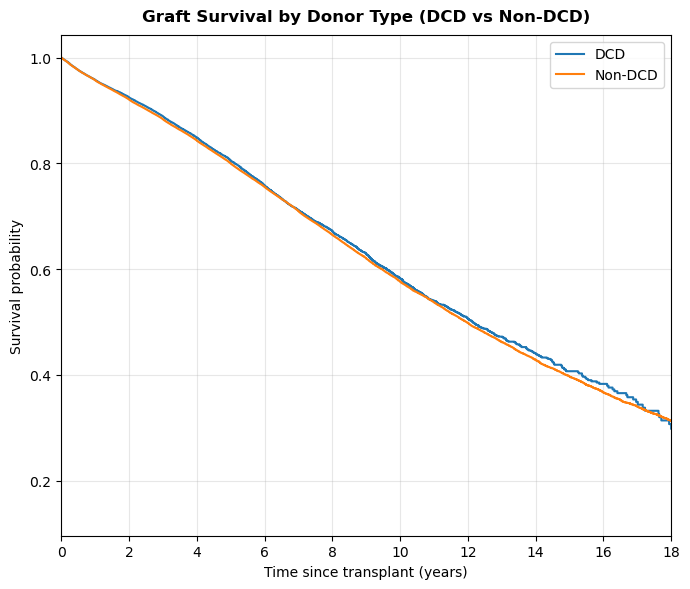

[dcd] n(1)=50,907, n(0)=177,948
DCD: Median = 14.3 yrs
Non-DCD: Median = 14.9 yrs
Log-rank χ² = 40.110, p = 2.401e-10
Saved TIFF to Fig3B.tif


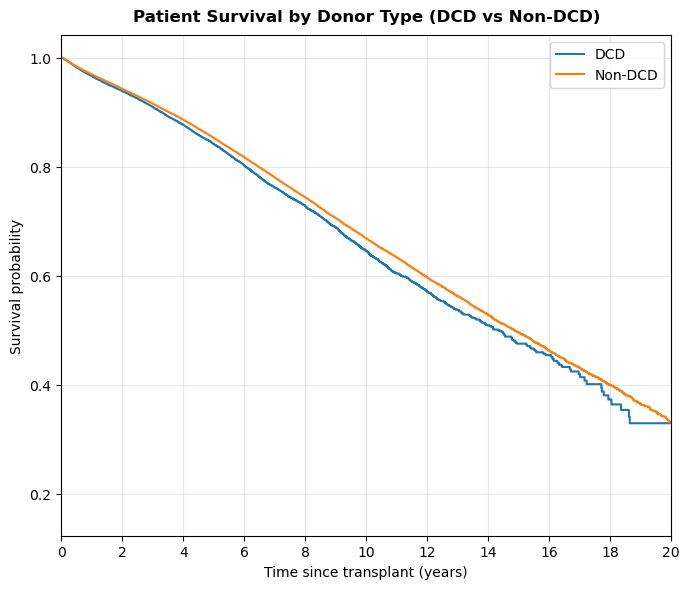

In [28]:
# ------------------------------------------------------------
# 1: GRAFT survival by DCD
# ------------------------------------------------------------
km_g1, km_g0, rt_g1, rt_g0 = km_logrank_binary(
    df_in=df_desc,
    time_col="time_graft_years",
    event_col="PSTATUS",
    group_col="dcd",
    labels=("DCD", "Non-DCD"),
    plot_title="Graft Survival by Donor Type (DCD vs Non-DCD)",
    save_path="Fig3A.tif"   # << just this
)

# If you want a single combined risk table to export:
risk_table_graft_dcd = pd.concat([rt_g1, rt_g0], ignore_index=True)
# risk_table_graft_dcd.to_csv("risk_table_graft_DCD_vs_nonDCD.csv", index=False)

# ------------------------------------------------------------
# 2: PATIENT survival by DCD 
# ------------------------------------------------------------
km_p1, km_p0, rt_p1, rt_p0 = km_logrank_binary(
    df_in=df_desc,
    time_col="time_death_years",
    event_col="PX_STAT",
    group_col="dcd",
    labels=("DCD", "Non-DCD"),
    plot_title="Patient Survival by Donor Type (DCD vs Non-DCD)",
    save_path="Fig3B.tif"   # << just this
)

risk_table_patient_dcd = pd.concat([rt_p1, rt_p0], ignore_index=True)
# risk_table_patient_dcd.to_csv("risk_table_patient_DCD_vs_nonDCD.csv", index=False)

##### Graft & Patient Survival by ECD Donor Status

[ECD_DONOR] n(1)=37,092, n(0)=191,763
ECD Donor: Median = 8.1 yrs
Non-ECD Donor: Median = 13.0 yrs
Log-rank χ² = 4150.031, p = 0
Saved TIFF to Fig3C.tif


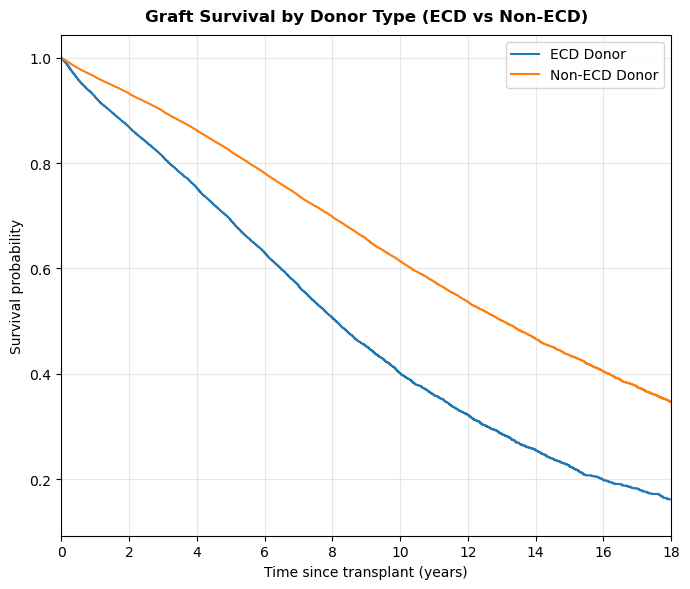

[ECD_DONOR] n(1)=37,092, n(0)=191,763
ECD Donor: Median = 10.4 yrs
Non-ECD Donor: Median = 15.8 yrs
Log-rank χ² = 2961.715, p = 0
Saved TIFF to Fig3D.tif


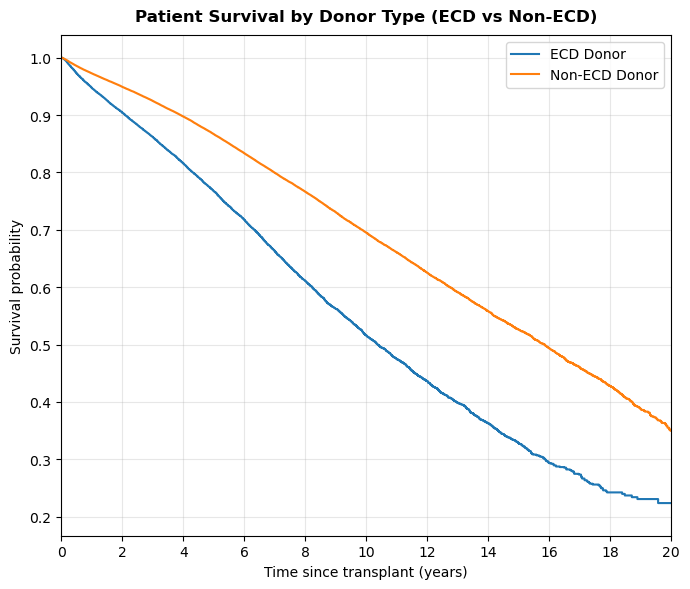

In [29]:
# --- Graft survival: ECD vs non-ECD donors
km_g1, km_g0, rt_g1, rt_g0 = km_logrank_binary(
    df_in=df_desc,
    time_col="time_graft_years",
    event_col="PSTATUS",
    group_col="ECD_DONOR",
    labels=("ECD Donor", "Non-ECD Donor"),
    plot_title="Graft Survival by Donor Type (ECD vs Non-ECD)",
    save_path="Fig3C.tif"   
)

risk_table_graft_ecd = pd.concat([rt_g1, rt_g0], ignore_index=True)
# risk_table_graft_ecd.to_csv("risk_table_graft_ECD_vs_nonECD.csv", index=False)

# --- Patient survival: ECD vs non-ECD donors
km_p1, km_p0, rt_p1, rt_p0 = km_logrank_binary(
    df_in=df_desc,
    time_col="time_death_years",
    event_col="PX_STAT",
    group_col="ECD_DONOR",
    labels=("ECD Donor", "Non-ECD Donor"),
    plot_title="Patient Survival by Donor Type (ECD vs Non-ECD)",
    save_path="Fig3D.tif"   # << just this
)

risk_table_patient_ecd = pd.concat([rt_p1, rt_p0], ignore_index=True)
# risk_table_patient_ecd.to_csv("risk_table_patient_ECD_vs_nonECD.csv", index=False)

##### Graft & Patient Survival by Recipient Diabetes

[diab] n(1)=82,998, n(0)=145,857
Diabetic: Median = 8.4 yrs
Non-Diabetic: Median = 15.3 yrs
Log-rank χ² = 8463.182, p = 0
Saved TIFF to Fig3E.tif


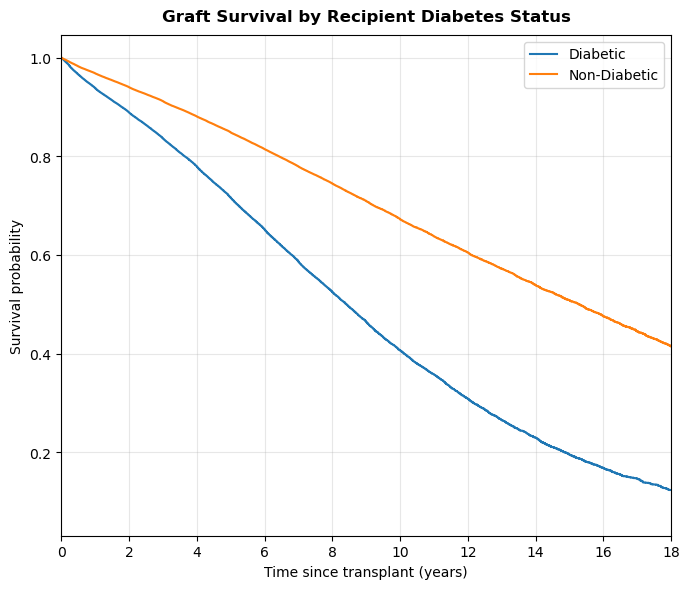

[diab] n(1)=82,998, n(0)=145,857
Diabetic: Median = 10.1 yrs
Non-Diabetic: Median = 17.9 yrs
Log-rank χ² = 7871.702, p = 0
Saved TIFF to Fig3F.tif


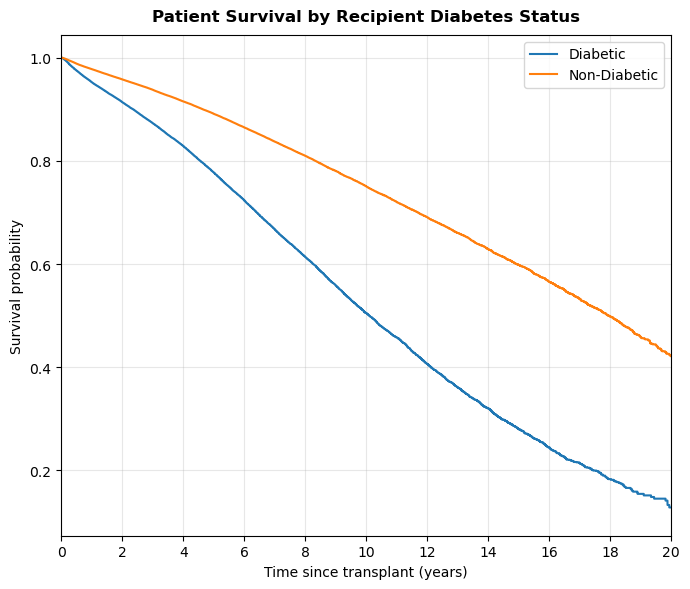

In [30]:
# --- Graft survival: diabetic vs non-diabetic recipients
km_g1, km_g0, rt_g1, rt_g0 = km_logrank_binary(
    df_in=df_desc,
    time_col="time_graft_years",
    event_col="PSTATUS",
    group_col="diab",
    labels=("Diabetic", "Non-Diabetic"),
    plot_title="Graft Survival by Recipient Diabetes Status",
    save_path="Fig3E.tif"  
)


risk_table_graft_diab = pd.concat([rt_g1, rt_g0], ignore_index=True)
# risk_table_graft_diab.to_csv("risk_table_graft_diab_vs_nondiab.csv", index=False)

# --- Patient survival: diabetic vs non-diabetic recipients
km_p1, km_p0, rt_p1, rt_p0 = km_logrank_binary(
    df_in=df_desc,
    time_col="time_death_years",
    event_col="PX_STAT",
    group_col="diab",
    labels=("Diabetic", "Non-Diabetic"),
    plot_title="Patient Survival by Recipient Diabetes Status",
    save_path="Fig3F.tif" 
)

risk_table_patient_diab = pd.concat([rt_p1, rt_p0], ignore_index=True)
# risk_table_patient_diab.to_csv("risk_table_patient_diab_vs_nondiab.csv", index=False)

##### KDPI QUARTILES: Graft & Patient Survival 

In [32]:
# ---------- Helper: ensure we can build risk tables from a fitted KMF ----------
def risk_table_from_kmf(kmf_fitted: KaplanMeierFitter, grid_years: np.ndarray) -> pd.DataFrame:
    evt_full = kmf_fitted.event_table.copy()      # includes '-inf' row
    n0 = int(evt_full.iloc[0]["at_risk"])
    evt = evt_full.iloc[1:].copy()                # drop '-inf'
    evt.index.name = "time_years"
    grid_index = pd.Index(grid_years, name="time_years")

    at_risk = (evt["at_risk"].reindex(grid_index, method="ffill")
                          .fillna(n0).round().astype(int))
    cum_events = evt["observed"].cumsum()
    cum_cens   = evt["censored"].cumsum()
    ce_grid = cum_events.reindex(grid_index, method="ffill").fillna(0.0)
    cc_grid = cum_cens.reindex(grid_index, method="ffill").fillna(0.0)

    events_int   = ce_grid.diff().fillna(ce_grid.iloc[0]).round().astype(int)
    censored_int = cc_grid.diff().fillna(cc_grid.iloc[0]).round().astype(int)

    return pd.DataFrame({
        "time_years": grid_years,
        "at_risk": at_risk.values,
        "events": events_int.values,
        "censored": censored_int.values
    })

In [33]:
# --------- Build KDPI quartiles on df_desc (robust to 0–1 vs 0–100) ----------
df_kdpi = df_desc.copy()

# Coerce KDPI numeric and normalize to 0–100 if needed
kdpi_raw = pd.to_numeric(df_kdpi["KDPI"], errors="coerce")
if kdpi_raw.max(skipna=True) <= 1.5:
    kdpi_norm = kdpi_raw * 100.0
else:
    kdpi_norm = kdpi_raw.copy()

# Compute quartile cutpoints on available KDPI
q = kdpi_norm.quantile([0.25, 0.50, 0.75]).to_dict()
bins   = [-np.inf, q[0.25], q[0.50], q[0.75], np.inf]
labels = ["KDPI Q1 (lowest)", "KDPI Q2", "KDPI Q3", "KDPI Q4 (highest)"]
df_kdpi["KDPI_quartile"] = pd.cut(kdpi_norm, bins=bins, labels=labels, include_lowest=True)

# ---------- Common plotting grid (years) ----------
def make_year_ticks(series_years, step=2.0):
    tmax = float(np.nanpercentile(series_years, 99.5))
    return np.arange(0, np.ceil(tmax / step) * step + 1e-9, step)

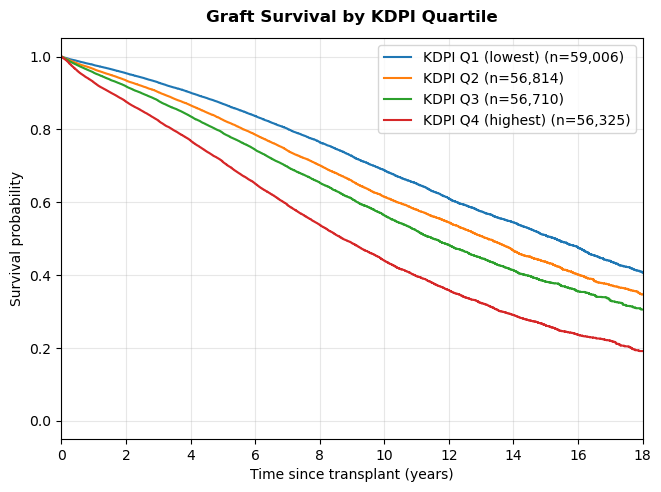

In [34]:
# ---------- GRAFT survival by KDPI quartile ----------
valid_g = df_kdpi["KDPI_quartile"].notna() & (df_kdpi["time_graft_years"] > 0)
ticks_g = make_year_ticks(df_kdpi.loc[valid_g, "time_graft_years"], step=2.0)

fig, ax = plt.subplots(figsize=(8.6, 5.2))
km_by_q_graft = {}
for lab in labels:
    m = valid_g & (df_kdpi["KDPI_quartile"] == lab)
    if m.sum() == 0: 
        continue
    km = KaplanMeierFitter(label=f"{lab} (n={int(m.sum()):,})")
    km.fit(df_kdpi.loc[m, "time_graft_years"], event_observed=df_kdpi.loc[m, "PSTATUS"])
    km.plot_survival_function(ax=ax, ci_show=False)
    km_by_q_graft[lab] = km

ax.set_title("Graft Survival by KDPI Quartile", pad=12, weight="bold")
ax.set_xlabel("Time since transplant (years)")
ax.set_ylabel("Survival probability")
ax.set_xlim(0, ticks_g[-1])
ax.set_xticks(ticks_g)
ax.grid(True, alpha=0.3)
ax.legend()
plt.gcf().set_size_inches(7.5, 5.2)
plt.savefig("Fig3G.tif", dpi=300, format="tiff", bbox_inches="tight")


In [35]:
# k-sample log-rank for graft
res_graft = multivariate_logrank_test(
    df_kdpi.loc[valid_g, "time_graft_years"],
    groups=df_kdpi.loc[valid_g, "KDPI_quartile"],
    event_observed=df_kdpi.loc[valid_g, "PSTATUS"]
)
print(f"[Graft] KDPI quartiles — multigroup log-rank χ²={res_graft.test_statistic:.3f}, p={res_graft.p_value:.4g}")

# Risk table per quartile (graft), aligned to same ticks
qtables_graft = []
for lab in labels:
    m = valid_g & (df_kdpi["KDPI_quartile"] == lab)
    if m.sum() == 0:
        continue
    km = KaplanMeierFitter().fit(
        df_kdpi.loc[m, "time_graft_years"],
        event_observed=df_kdpi.loc[m, "PSTATUS"],
        label=str(lab)
    )
    tdf = risk_table_from_kmf(km, ticks_g)
    tdf.insert(0, "group", str(lab))
    qtables_graft.append(tdf)

risk_table_kdpi_graft = pd.concat(qtables_graft, ignore_index=True)
# risk_table_kdpi_graft.to_csv("risk_table_kdpi_quartiles_graft.csv", index=False)

[Graft] KDPI quartiles — multigroup log-rank χ²=5420.450, p=0


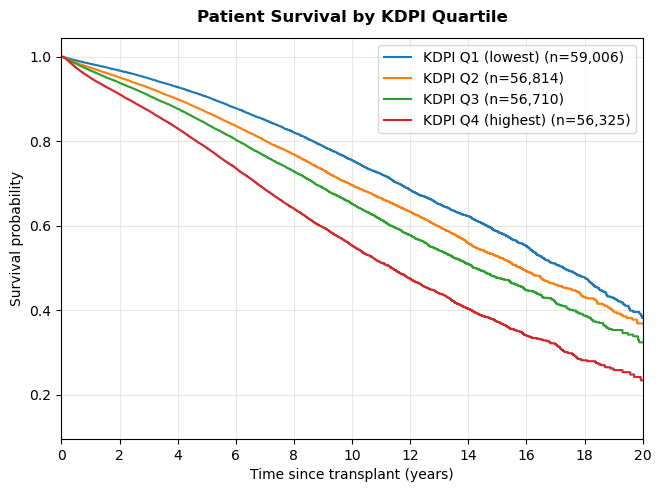

In [36]:
# ---------- 2) PATIENT survival by KDPI quartile ----------
valid_p = df_kdpi["KDPI_quartile"].notna() & (df_kdpi["time_death_years"] > 0)
ticks_p = make_year_ticks(df_kdpi.loc[valid_p, "time_death_years"], step=2.0)

fig, ax = plt.subplots(figsize=(8.6, 5.2))
km_by_q_pat = {}
for lab in labels:
    m = valid_p & (df_kdpi["KDPI_quartile"] == lab)
    if m.sum() == 0:
        continue
    km = KaplanMeierFitter(label=f"{lab} (n={int(m.sum()):,})")
    km.fit(df_kdpi.loc[m, "time_death_years"], event_observed=df_kdpi.loc[m, "PX_STAT"])
    km.plot_survival_function(ax=ax, ci_show=False)
    km_by_q_pat[lab] = km

ax.set_title("Patient Survival by KDPI Quartile", pad=12, weight="bold")
ax.set_xlabel("Time since transplant (years)")
ax.set_ylabel("Survival probability")
ax.set_xlim(0, ticks_p[-1])
ax.set_xticks(ticks_p)
ax.grid(True, alpha=0.3)
ax.legend()
plt.gcf().set_size_inches(7.5, 5.2)
plt.savefig("Fig3H.tif", dpi=300, format="tiff", bbox_inches="tight")


In [38]:
# k-sample log-rank for patient survival
res_pat = multivariate_logrank_test(
    df_kdpi.loc[valid_p, "time_death_years"],
    groups=df_kdpi.loc[valid_p, "KDPI_quartile"],
    event_observed=df_kdpi.loc[valid_p, "PX_STAT"]
)
print(f"[Patient] KDPI quartiles — multigroup log-rank χ²={res_pat.test_statistic:.3f}, p={res_pat.p_value:.4g}")


# Risk table per quartile (patient), aligned to same ticks
qtables_pat = []
for lab in labels:
    m = valid_p & (df_kdpi["KDPI_quartile"] == lab)
    if m.sum() == 0:
        continue
    km = KaplanMeierFitter().fit(
        df_kdpi.loc[m, "time_death_years"],
        event_observed=df_kdpi.loc[m, "PX_STAT"],
        label=str(lab)
    )
    tdf = risk_table_from_kmf(km, ticks_p)
    tdf.insert(0, "group", str(lab))
    qtables_pat.append(tdf)

risk_table_kdpi_patient = pd.concat(qtables_pat, ignore_index=True)
# risk_table_kdpi_patient.to_csv("risk_table_kdpi_quartiles_patient.csv", index=False)

[Patient] KDPI quartiles — multigroup log-rank χ²=3746.917, p=0


#### Table 1 (baseline cohort characteristics)

In [41]:
# ======== CONFIG / INPUT ========
df_stat = df_desc.copy()

# -----------------------
# Robust helpers
# -----------------------
_TRUE = {"1","Y","YES","TRUE",1,True}
_FALSE= {"0","N","NO","FALSE",0,False}

def to01_series(s: pd.Series) -> pd.Series:
    """
    Robustly map a binary-like column to 0/1:
    accepts 1/0, '1'/'0', Y/N, Yes/No, True/False, categories.
    Non-matching non-null values are treated as 0 (conservative).
    """
    if s is None:
        return pd.Series(dtype="Int8")

    # Work on string upper for strings, leave numbers/bools alone
    m = s.copy()
    # try direct numeric first
    num = pd.to_numeric(m, errors="coerce")
    if num.notna().any():
        # anything > 0 becomes 1; else 0
        out = (num.fillna(0) > 0).astype("Int8")
        return out

    # non-numeric path
    u = m.astype("string").str.strip().str.upper()
    out = pd.Series(0, index=s.index, dtype="Int8")
    out[u.isin(_TRUE)] = 1
    out[u.isin(_FALSE)] = 0
    # anything else stays 0
    return out

def n_pct(s: pd.Series) -> str:
    """
    Return 'n (p%)' for a binary/categorical indicator where "positive" is 1/True/Y/etc.
    Denominator = non-missing after mapping.
    """
    x = to01_series(s)
    denom = x.notna().sum()
    num = int(x.fillna(0).sum())
    p = (num / denom * 100.0) if denom else np.nan
    return f"{num:,} ({p:.1f}%)" if denom else "NA"

def counts_by_level(series: pd.Series) -> dict:
    """
    For multi-level categorical variables: return dict of {level: 'n (p%)'}.
    Denominator = non-missing.
    """
    s = series.copy()
    denom = s.notna().sum()
    vc = s.value_counts(dropna=False)  # includes explicit NaN count
    out = {}
    for lvl, n in vc.items():
        if pd.isna(lvl):
            continue
        p = (n/denom*100.0) if denom else np.nan
        out[str(lvl)] = f"{int(n):,} ({p:.1f}%)"
    return out

def median_iqr(series) -> str:
    x = pd.to_numeric(series, errors="coerce").dropna()
    if len(x)==0: return "NA"
    med = float(np.median(x)); q1, q3 = np.percentile(x, [25,75])
    return f"{med:.1f} ({q1:.1f}–{q3:.1f})"

def median_iqr_pct(series) -> str:
    x = pd.to_numeric(series, errors="coerce").dropna()
    if len(x)==0: return "NA"
    med = float(np.median(x)); q1, q3 = np.percentile(x, [25,75])
    return f"{med:.0f}% ({q1:.0f}–{q3:.0f}%)"

def section_to_df(section_name, mapping: dict) -> pd.DataFrame:
    return pd.DataFrame({"Section":section_name,
                         "Characteristic": list(mapping.keys()),
                         "Value": list(mapping.values())})

def km_probs(df_in, time_col, event_col, years=[1,3,5,10]):
    dfx = df_in.copy()
    dfx = dfx[np.isfinite(dfx[time_col]) & (dfx[time_col] > 0)]
    if len(dfx)==0:
        return {f"{t}-yr survival":"NA" for t in years}
    kmf = KaplanMeierFitter()
    kmf.fit(durations=dfx[time_col], event_observed=dfx[event_col])
    out = {}
    for t in years:
        try:
            sp = float(kmf.predict(t))
            out[f"{t}-yr survival"] = f"{100*sp:.1f}%"
        except Exception:
            out[f"{t}-yr survival"] = "NA"
    return out



In [42]:
# -----------------------
# Build categories if missing (consistent with previous steps)
# -----------------------
# Induction category (derive if absent)
if "induction_cat" not in df_stat.columns:
    i_bas_thy = to01_series(df_stat.get("i_bas_thy", 0))
    i_thy     = to01_series(df_stat.get("i_thy", 0))
    i_ale     = to01_series(df_stat.get("i_ale", 0))
    i_bas     = to01_series(df_stat.get("i_bas", 0))
    df_stat["induction_cat"] = np.select(
        [
            (i_bas_thy==1),
            (i_thy==1) & (i_bas==0),
            (i_ale==1) & (i_thy==0) & (i_bas==0),
            (i_bas==1) & (i_thy==0)
        ],
        [
            "Thymoglobulin + Basiliximab",
            "Thymoglobulin",
            "Alemtuzumab",
            "Basiliximab",
        ],
        default="No induction"
    )

# Maintenance category (derive if absent)
if "maintenance_cat" not in df_stat.columns:
    c_mmf_s = to01_series(df_stat.get("c_ci_mmf_steroids", 0))
    c_mmf   = to01_series(df_stat.get("c_ci_mmf", 0))
    df_stat["maintenance_cat"] = np.select(
        [(c_mmf_s==1), (c_mmf==1)],
        ["CNI + MMF + steroids","CNI + MMF"],
        default="Other regimens"
    )

# -----------------------
# KDPI median (IQR) as percent, robust to 0–1 input
# -----------------------
_kdpi = pd.to_numeric(df_stat["KDPI"], errors="coerce")
kdpi_display = median_iqr_pct(_kdpi*100.0) if _kdpi.max(skipna=True) <= 1.5 else median_iqr_pct(_kdpi)

In [43]:
# -----------------------
# TABLE 1: Baseline cohort with N (%) everywhere for binary/cat
# -----------------------
N = len(df_stat)

# Recipient race is encoded as multiple binary flags in your schema.
# We'll show each as N (%). Same for other binary fields.
recip_block = {
    "Recipient age (y), median (IQR)": median_iqr(df_stat["AGE"]),
    "Male — n (%)":                 n_pct(df_stat["male_pt"]),
    "White — n (%)":                n_pct(df_stat["white_pt"]),
    "Black — n (%)":                n_pct(df_stat["black_pt"]),
    "Hispanic — n (%)":             n_pct(df_stat["hisp_pt"]),
    "Asian — n (%)":                n_pct(df_stat["asian_pt"]),
    "Retransplant — n (%)":         n_pct(df_stat["retx"]),
    "On dialysis — n (%)":          n_pct(df_stat["ON_DIALYSIS"]),  # <-- fixed: no *_bin
    "Diabetes — n (%)":             n_pct(df_stat["diab"]),
    "BMI (kg/m²), median (IQR)":    median_iqr(df_stat["BMI_CALC"]),
    "cPRA (%), median (IQR)":       median_iqr(df_stat["END_CPRA"]),
    "Wait time (days), median (IQR)": median_iqr(df_stat["DAYSWAIT_CHRON"]),
    "Recipient creatinine (mg/dL), median (IQR)": median_iqr(df_stat["CREAT_TRR"]),
}

donor_block = {
    "Donor age (y), median (IQR)":         median_iqr(df_stat["AGE_DON"]),
    "Male donor — n (%)":                  n_pct(df_stat["male_don"]),
    "White donor — n (%)":                 n_pct(df_stat["white_don"]),
    "Black donor — n (%)":                 n_pct(df_stat["black_don"]),
    "Hispanic donor — n (%)":              n_pct(df_stat["hisp_don"]),
    "Asian donor — n (%)":                 n_pct(df_stat["asian_don"]),
    "DCD — n (%)":                         n_pct(df_stat["dcd"]),
    "ECD — n (%)":                         n_pct(df_stat["ECD_DONOR"]),
    "Donor diabetes — n (%)":              n_pct(df_stat["diab_don"]),
    "Donor hypertension — n (%)":          n_pct(df_stat["hyper_don"]),
    "Donor BMI (kg/m²), median (IQR)":     median_iqr(df_stat["BMI_DON_CALC"]),
    "KDPI, median (IQR)":                  kdpi_display,
    "Donor creatinine (mg/dL), median (IQR)": median_iqr(df_stat["CREAT_DON"]),
}

tx_block = {
    "Cold ischemia time (h), median (IQR)": median_iqr(df_stat["COLD_ISCH_KI"]),
    "Local allocation — n (%)":             n_pct(df_stat["local"]),
    "Regional allocation — n (%)":          n_pct(df_stat["regional"]),
    "National allocation — n (%)":          n_pct(df_stat["national"]),
}

# Categorical distributions for induction / maintenance
def dict_counts(series: pd.Series) -> dict:
    d = counts_by_level(series)
    # optional ordering tweak:
    order = [
        "Thymoglobulin + Basiliximab","Thymoglobulin","Alemtuzumab","Basiliximab","None/Other",
        "CNI + MMF + steroids","CNI + MMF","Other/Not CNI+MMF"
    ]
    out = {}
    for k in order:
        if k in d: out[k] = d[k]
    for k,v in d.items():  # append any leftover levels
        if k not in out: out[k]=v
    return out

ind_block   = dict_counts(df_stat["induction_cat"])
maint_block = dict_counts(df_stat["maintenance_cat"])

table1 = pd.concat([
    section_to_df("Study Cohort", {"Total transplants — n": f"{N:,}"}),
    section_to_df("Recipient Characteristics", recip_block),
    section_to_df("Donor Characteristics", donor_block),
    section_to_df("Transplant Factors", tx_block),
    section_to_df("Induction Regimen", ind_block),
    section_to_df("Maintenance Regimen", maint_block),
], ignore_index=True)[["Section","Characteristic","Value"]]

print("\n" + "="*72)
print("TABLE 1. Baseline Cohort Characteristics")
print("="*72)
print(table1.to_string(index=False))


TABLE 1. Baseline Cohort Characteristics
                  Section                             Characteristic                Value
             Study Cohort                      Total transplants — n              228,855
Recipient Characteristics            Recipient age (y), median (IQR)     55.0 (44.0–63.0)
Recipient Characteristics                               Male — n (%)      138,269 (60.4%)
Recipient Characteristics                              White — n (%)       90,383 (39.5%)
Recipient Characteristics                              Black — n (%)       76,765 (33.5%)
Recipient Characteristics                           Hispanic — n (%)       40,658 (17.8%)
Recipient Characteristics                              Asian — n (%)        16,069 (7.0%)
Recipient Characteristics                       Retransplant — n (%)       27,819 (12.2%)
Recipient Characteristics                        On dialysis — n (%)      189,966 (83.0%)
Recipient Characteristics                           Diabet

In [44]:
# -----------------------
# TABLE 2: outcome overview(s)
# -----------------------
def outcome_overview(df_in, time_col_years, event_col, label):
    dfx = df_in[np.isfinite(df_in[time_col_years]) & (df_in[time_col_years] > 0)].copy()
    Nloc   = len(dfx)
    events = int(to01_series(dfx[event_col]).sum())
    cens   = int(Nloc - events)
    event_rate = f"{(100*events/Nloc):.1f}%" if Nloc else "NA"
    fol_all = median_iqr(dfx[time_col_years])
    mask_e  = to01_series(dfx[event_col])==1
    fol_e   = median_iqr(dfx.loc[mask_e, time_col_years])
    fol_c   = median_iqr(dfx.loc[~mask_e, time_col_years])
    survs   = km_probs(dfx.assign(**{event_col: to01_series(dfx[event_col])}),
                       time_col_years, event_col, years=[1,3,5,10])
    block = {
        "Outcome": label,
        "N (analysis set)": f"{Nloc:,}",
        "Events — n": f"{events:,}",
        "Censored — n": f"{cens:,}",
        "Event rate": event_rate,
        "Follow-up (years), overall — median (IQR)": fol_all,
        "Follow-up (years), event group — median (IQR)": fol_e,
        "Follow-up (years), censored group — median (IQR)": fol_c,
        **survs
    }
    return block

rows = []
rows.append(outcome_overview(df_stat, "time_graft_years", "PSTATUS",
                             "Graft failure (death-censored)"))
rows.append(outcome_overview(df_stat, "time_death_years", "PX_STAT",
                             "Patient mortality (all-cause)"))

# OPTIONAL: include composite all-cause graft failure (death or graft failure)
include_composite = True
if include_composite and ("time_all" in df_stat.columns) and ("event_all" in df_stat.columns):
    # ensure types:
    df_stat["time_all_years"]  = pd.to_numeric(df_stat["time_all"], errors="coerce") / 365.25
    df_stat["event_all01"]     = to01_series(df_stat["event_all"])
    rows.append(outcome_overview(df_stat.rename(columns={"time_all_years":"time_all_y",
                                                         "event_all01":"event_all01"}),
                                 "time_all_y", "event_all01",
                                 "All-cause graft failure (graft failure or death)"))

table2 = pd.DataFrame(rows)[[
    "Outcome","N (analysis set)","Events — n","Censored — n","Event rate",
    "Follow-up (years), overall — median (IQR)",
    "Follow-up (years), event group — median (IQR)",
    "Follow-up (years), censored group — median (IQR)",
    "1-yr survival","3-yr survival","5-yr survival","10-yr survival"
]]

print("\n" + "="*72)
print("TABLE 2. Event & Censoring Overview with KM Survival")
print("="*72)
print(table2.to_string(index=False))


TABLE 2. Event & Censoring Overview with KM Survival
                       Outcome N (analysis set) Events — n Censored — n Event rate Follow-up (years), overall — median (IQR) Follow-up (years), event group — median (IQR) Follow-up (years), censored group — median (IQR) 1-yr survival 3-yr survival 5-yr survival 10-yr survival
Graft failure (death-censored)          228,855     55,346      173,509      24.2%                             4.0 (1.9–7.0)                                 3.9 (1.6–6.6)                                    4.0 (2.0–7.0)         95.7%         88.5%         80.1%          57.8%
 Patient mortality (all-cause)          228,855     43,772      185,083      19.1%                             4.3 (2.0–7.2)                                 4.1 (1.8–6.9)                                    4.5 (2.0–7.3)         96.8%         91.4%         85.1%          66.5%


In [45]:
# Optional saves
table1.to_csv("table1_baseline_characteristics.csv", index=False)
table2.to_csv("table2_event_overview_survival.csv", index=False)

All-cause graft failure (includes death as failure)”

#### Check for Multicollinearity
Before fitting the Cox PH model, check whether predictors are redundant.
1. Prepare dataset
    - Encode categorical variables (e.g., immunosuppressive regimen, race).
    - Standardize continuous predictors (mean 0, variance 1).

In [46]:
# =========================
# Multicollinearity (VIF)
# =========================

from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [47]:
# Make a working copy 
df_model = df_desc.copy()

#Check the datatype
print("\n=== df_model.info() ===")
df_model.info(memory_usage="deep")

# counts by dtype
dtype_counts = df_model.dtypes.value_counts()
print("\n=== Dtype counts ===")
print(dtype_counts)

# List columns by broad dtype groups (helps plan VIF/Cox design)
num_cols  = df_model.select_dtypes(include=["number"]).columns.tolist()
cat_cols  = df_model.select_dtypes(include=["category"]).columns.tolist()
obj_cols  = df_model.select_dtypes(include=["object","string"]).columns.tolist()
bool_cols = df_model.select_dtypes(include=["bool"]).columns.tolist()

print("\n# numeric columns:", len(num_cols))
print(num_cols[:30], "..." if len(num_cols) > 30 else "")
print("\n# category columns:", len(cat_cols))
print(cat_cols[:30], "..." if len(cat_cols) > 30 else "")
print("\n# object/string columns:", len(obj_cols))
print(obj_cols[:30], "..." if len(obj_cols) > 30 else "")
print("\n# bool columns:", len(bool_cols))
print(bool_cols[:30], "..." if len(bool_cols) > 30 else "")



=== df_model.info() ===
<class 'pandas.core.frame.DataFrame'>
Index: 228855 entries, 0 to 343789
Data columns (total 48 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   i_thy                 228855 non-null  category
 1   i_ale                 228855 non-null  category
 2   i_bas                 228855 non-null  category
 3   i_bas_thy             228855 non-null  category
 4   c_ci_mmf              228855 non-null  category
 5   c_ci_mmf_steroids     228855 non-null  category
 6   AGE                   228855 non-null  int16   
 7   male_pt               228855 non-null  category
 8   white_pt              228855 non-null  category
 9   black_pt              228855 non-null  category
 10  hisp_pt               228855 non-null  category
 11  asian_pt              228855 non-null  category
 12  retx                  228855 non-null  category
 13  DAYSWAIT_CHRON        228855 non-null  float32 
 14  ON_DIALYSIS     

In [48]:
# --- Convert binary/categorical flags to strict 0/1 (no new variables created) ---
binary_cols = [
    'i_thy','i_ale','i_bas','i_bas_thy',
    'c_ci_mmf','c_ci_mmf_steroids',
    'male_pt','white_pt','black_pt','hisp_pt','asian_pt','retx',
    'ON_DIALYSIS','diab',
    'male_don','white_don','black_don','hisp_don','asian_don',
    'diab_don','hyper_don',
    'dcd','ECD_DONOR',
    'local','regional','national'
]

def to_01(s: pd.Series) -> pd.Series:
    """
    Robust 0/1 mapper that respects your existing encodings:
    - numeric: >0 -> 1 else 0
    - strings/categories: 'Y','YES','TRUE','1' -> 1; 'N','NO','FALSE','0' -> 0
    - everything else non-missing defaults to 0
    """
    # numeric path first
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return (num.fillna(0) > 0).astype("Int8")

    # fallback for non-numeric
    u = s.astype("string").str.strip().str.upper()
    true_set  = {"1","Y","YES","TRUE"}
    false_set = {"0","N","NO","FALSE"}
    out = pd.Series(0, index=s.index, dtype="Int8")
    out[u.isin(true_set)]  = 1
    out[u.isin(false_set)] = 0
    return out

# Convert only the columns that are present (no creation/deletion)
for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = to_01(df_model[col])

# --- Quick sanity peek to confirm mapping (no mutations) ---
check_peek = [c for c in binary_cols if c in df_model.columns][:10]
for c in check_peek:
    vc = df_model[c].value_counts(dropna=False)
    print(f"{c}: {vc.to_dict()}")

i_thy: {np.int8(1): 136458, np.int8(0): 92397}
i_ale: {np.int8(0): 200873, np.int8(1): 27982}
i_bas: {np.int8(0): 184343, np.int8(1): 44512}
i_bas_thy: {np.int8(0): 220629, np.int8(1): 8226}
c_ci_mmf: {np.int8(0): 173218, np.int8(1): 55637}
c_ci_mmf_steroids: {np.int8(1): 153515, np.int8(0): 75340}
male_pt: {np.int8(1): 138269, np.int8(0): 90586}
white_pt: {np.int8(0): 138472, np.int8(1): 90383}
black_pt: {np.int8(0): 152090, np.int8(1): 76765}
hisp_pt: {np.int8(0): 188197, np.int8(1): 40658}


In [49]:
# --- Exclude outcomes & survival times from the predictor matrix (do NOT drop from df_model) ---
exclude_outcomes = [
    'PSTATUS','PX_STAT',        # patient/graft event flags
    'event_graft','event_death','event_all'
]
exclude_times = [
    'GTIME_KI','PTIME',         # raw day counts
    'time_graft','time_death','time_all',
    'time_graft_years','time_death_years'
]
# EXCLUDE missingness flags from predictors for VIF
exclude_misc = ['END_CPRA_missing','COLD_ISCH_KI_missing']

exclude_cols = set(exclude_outcomes + exclude_times + exclude_misc)

# Predictor columns = everything else that remains after exclusion
predictor_cols = [c for c in df_model.columns if c not in exclude_cols]

print("\n# of predictor columns (pre-standardization):", len(predictor_cols))
#print("Sample predictors:", predictor_cols[:20], "..." if len(predictor_cols) > 20 else "")
predictor_cols


# of predictor columns (pre-standardization): 36


['i_thy',
 'i_ale',
 'i_bas',
 'i_bas_thy',
 'c_ci_mmf',
 'c_ci_mmf_steroids',
 'AGE',
 'male_pt',
 'white_pt',
 'black_pt',
 'hisp_pt',
 'asian_pt',
 'retx',
 'DAYSWAIT_CHRON',
 'ON_DIALYSIS',
 'CREAT_TRR',
 'END_CPRA',
 'BMI_CALC',
 'diab',
 'AGE_DON',
 'male_don',
 'white_don',
 'black_don',
 'hisp_don',
 'asian_don',
 'CREAT_DON',
 'diab_don',
 'hyper_don',
 'BMI_DON_CALC',
 'KDPI',
 'dcd',
 'ECD_DONOR',
 'COLD_ISCH_KI',
 'local',
 'regional',
 'national']

In [50]:
# --- Standardize continuous variables ONLY (keep 0/1 flags as-is) ---
continuous_vars = [
    'AGE','DAYSWAIT_CHRON','CREAT_TRR','END_CPRA','BMI_CALC',
    'AGE_DON','CREAT_DON','BMI_DON_CALC','KDPI','COLD_ISCH_KI'
]
# Limit to those present and in the predictor set
cont_in_X = [c for c in continuous_vars if c in predictor_cols and c in df_model.columns]

# Build X (features only), drop rows with missing predictors to avoid VIF crashes later
X = df_model[predictor_cols].copy()

# Ensure numeric dtype for continuous columns before scaling
for c in cont_in_X:
    X[c] = pd.to_numeric(X[c], errors="coerce")

# You can choose either: (a) drop rows with any NaN in predictors, or (b) impute first.
# drop for the VIF step:
X = X.dropna(axis=0)

# Scale continuous variables in-place; leave binary flags untouched
scaler = StandardScaler()
for c in cont_in_X:
    X[c] = scaler.fit_transform(X[[c]])

print("\nPrepared feature matrix X for multicollinearity checks:")
print("Shape:", X.shape)
print("Continuous variables standardized:", cont_in_X)
print("Binary/flag variables left as 0/1:", [c for c in predictor_cols if c not in cont_in_X][:15], "...")



Prepared feature matrix X for multicollinearity checks:
Shape: (228855, 36)
Continuous variables standardized: ['AGE', 'DAYSWAIT_CHRON', 'CREAT_TRR', 'END_CPRA', 'BMI_CALC', 'AGE_DON', 'CREAT_DON', 'BMI_DON_CALC', 'KDPI', 'COLD_ISCH_KI']
Binary/flag variables left as 0/1: ['i_thy', 'i_ale', 'i_bas', 'i_bas_thy', 'c_ci_mmf', 'c_ci_mmf_steroids', 'male_pt', 'white_pt', 'black_pt', 'hisp_pt', 'asian_pt', 'retx', 'ON_DIALYSIS', 'diab', 'male_don'] ...


In [51]:
# --- Make a safe numeric copy for VIF ---
X_vif = X.copy()

# 1) Force every column to numeric float64
for c in X_vif.columns:
    X_vif[c] = pd.to_numeric(X_vif[c], errors="coerce").astype("float64")

# 2) Replace inf/-inf with NaN (then drop)
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)

# 3) Drop rows with any NaN to avoid OLS errors inside VIF
X_vif = X_vif.dropna(axis=0)

# 4) Compute VIF (no constant)
vals = X_vif.values  # guaranteed float64 now

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(vals, i) for i in range(vals.shape[1])]
})

# 5) Report
vif_sorted = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("VIF Diagnostics (numeric matrix):")
print("="*70)
print(vif_sorted.to_string(index=False))


VIF Diagnostics (numeric matrix):
          Feature       VIF
            local 96.476520
         national 31.945488
         regional 23.223449
        white_don 15.086418
         white_pt 11.778954
         black_pt 11.023623
         hisp_don  9.231209
        black_don  8.757557
          hisp_pt  7.581889
            i_thy  5.149051
             KDPI  4.363511
            i_bas  3.984519
         asian_pt  3.983606
            i_ale  3.075945
          AGE_DON  3.026951
         c_ci_mmf  2.994224
c_ci_mmf_steroids  2.930644
        asian_don  2.606442
        ECD_DONOR  1.760697
        i_bas_thy  1.684063
        hyper_don  1.574188
              AGE  1.420595
         END_CPRA  1.405702
        CREAT_TRR  1.304909
              dcd  1.281105
         diab_don  1.277823
             retx  1.273705
     COLD_ISCH_KI  1.267762
     BMI_DON_CALC  1.234453
             diab  1.199299
          male_pt  1.156529
         male_don  1.155798
        CREAT_DON  1.122368
         BMI_

In [52]:
# --- Clean summary bins that add up exactly to total ---
n_total = len(vif_sorted)

n_gt10  = int((vif_sorted["VIF"] > 10).sum())
n_5_10  = int(((vif_sorted["VIF"] > 5) & (vif_sorted["VIF"] <= 10)).sum())
n_le5   = int((vif_sorted["VIF"] <= 5).sum())

print("\n" + "-"*70)
print("VIF summary (disjoint bins)")
print("-"*70)
print(f"Total predictors         : {n_total}")
print(f"> 10 (severe)            : {n_gt10}")
print(f"> 5 and ≤ 10 (moderate)  : {n_5_10}")
print(f"≤ 5 (acceptable)         : {n_le5}")

# sanity check
assert n_gt10 + n_5_10 + n_le5 == n_total, "VIF bin counts do not sum to total!"

# optional: show the offenders per bin
print("\nTop offenders (>10):")
print(vif_sorted[vif_sorted["VIF"] > 10][["Feature","VIF"]].to_string(index=False))

print("\nModerate (5–10):")
print(vif_sorted[(vif_sorted["VIF"] > 5) & (vif_sorted["VIF"] <= 10)][["Feature","VIF"]]
      .sort_values("VIF", ascending=False).to_string(index=False))



----------------------------------------------------------------------
VIF summary (disjoint bins)
----------------------------------------------------------------------
Total predictors         : 36
> 10 (severe)            : 6
> 5 and ≤ 10 (moderate)  : 4
≤ 5 (acceptable)         : 26

Top offenders (>10):
  Feature       VIF
    local 96.476520
 national 31.945488
 regional 23.223449
white_don 15.086418
 white_pt 11.778954
 black_pt 11.023623

Moderate (5–10):
  Feature      VIF
 hisp_don 9.231209
black_don 8.757557
  hisp_pt 7.581889
    i_thy 5.149051


In [53]:
# =========================
# IMPROVED Multicollinearity (VIF) Analysis
# =========================

def prepare_features_for_vif(df, drop_reference_categories=True):
    """
    Properly prepare features for VIF analysis with correct reference category handling
    """
    df_model = df_desc.copy()
    
    # Convert binary columns to 0/1 (your existing function works well)
    binary_cols = [
        'i_thy','i_ale','i_bas','i_bas_thy',
        'c_ci_mmf','c_ci_mmf_steroids',
        'male_pt','white_pt','black_pt','hisp_pt','asian_pt','retx',
        'ON_DIALYSIS','diab',
        'male_don','white_don','black_don','hisp_don','asian_don',
        'diab_don','hyper_don',
        'dcd','ECD_DONOR',
        'local','regional','national'
    ]
    
    for col in binary_cols:
        if col in df_model.columns:
            df_model[col] = to_01(df_model[col])
    
    # EXCLUDE outcomes and time variables
    exclude_cols = [
        'PSTATUS','PX_STAT','event_graft','event_death','event_all',
        'GTIME_KI','PTIME','time_graft','time_death','time_all',
        'time_graft_years','time_death_years',
        'END_CPRA_missing','COLD_ISCH_KI_missing'
    ]
    
    predictor_cols = [c for c in df_model.columns if c not in exclude_cols]
    
    if drop_reference_categories:
        # =====================================================================
        # CRITICAL: Define and drop ONE reference category per categorical group
        # =====================================================================
        
        # Geographic variables: keep regional, national; drop local as reference
        if all(x in predictor_cols for x in ['local', 'regional', 'national']):
            predictor_cols = [c for c in predictor_cols if c != 'local']
            print("Dropped 'local' as geographic reference category")
        
        # Recipient race: keep black, hisp, asian; drop white as reference
        if all(x in predictor_cols for x in ['white_pt', 'black_pt', 'hisp_pt', 'asian_pt']):
            predictor_cols = [c for c in predictor_cols if c != 'white_pt']
            print("Dropped 'white_pt' as recipient race reference category")
        
        # Donor race: keep black, hisp, asian; drop white as reference  
        if all(x in predictor_cols for x in ['white_don', 'black_don', 'hisp_don', 'asian_don']):
            predictor_cols = [c for c in predictor_cols if c != 'white_don']
            print("Dropped 'white_don' as donor race reference category")
        
        # Immunosuppression: if these are mutually exclusive regimens
        # Keep only n-1 categories if they sum to 1 for each patient
        immuno_vars = ['i_thy', 'i_ale', 'i_bas', 'i_bas_thy']
        if all(x in predictor_cols for x in immuno_vars):
            # Check if they sum to 1 (mutually exclusive)
            immuno_sum = df_model[immuno_vars].sum(axis=1)
            if (immuno_sum == 1).all():  # Mutually exclusive
                predictor_cols = [c for c in predictor_cols if c != 'i_thy']
                print("Dropped 'i_thy' as immunosuppression reference category")
    
    return df_model, predictor_cols

def calculate_vif_safely(df, predictor_cols, max_iter=3, vif_threshold=10):
    """
    Iterative VIF calculation with automatic handling of problematic variables
    """
    # Prepare X matrix
    X = df_model[predictor_cols].copy()
    
    # Handle continuous variables
    continuous_vars = [
        'AGE','DAYSWAIT_CHRON','CREAT_TRR','END_CPRA','BMI_CALC',
        'AGE_DON','CREAT_DON','BMI_DON_CALC','KDPI','COLD_ISCH_KI'
    ]
    cont_in_X = [c for c in continuous_vars if c in X.columns]
    
    # Ensure numeric and scale continuous variables
    for c in cont_in_X:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    
    # Drop rows with missing values
    X = X.dropna()
    
    # Scale continuous variables
    scaler = StandardScaler()
    for c in cont_in_X:
        X[c] = scaler.fit_transform(X[[c]])
    
    # Force all to numeric for VIF
    X_vif = X.astype('float64').replace([np.inf, -np.inf], np.nan).dropna()
    
    # Iterative VIF removal
    high_vif_vars = []
    iteration = 0
    
    while iteration < max_iter:
        vals = X_vif.values
        vif_data = pd.DataFrame({
            "Feature": X_vif.columns,
            "VIF": [variance_inflation_factor(vals, i) for i in range(vals.shape[1])]
        }).sort_values("VIF", ascending=False)
        
        max_vif = vif_data['VIF'].max()
        if max_vif <= vif_threshold:
            break
            
        # Remove variable with highest VIF
        worst_var = vif_data.iloc[0]['Feature']
        high_vif_vars.append(worst_var)
        X_vif = X_vif.drop(columns=[worst_var])
        print(f"Iteration {iteration + 1}: Removed '{worst_var}' (VIF: {max_vif:.2f})")
        
        iteration += 1
    
    return vif_data, high_vif_vars

# =============================================================================
# RUN THE IMPROVED ANALYSIS
# =============================================================================

print("=" * 70)
print("IMPROVED MULTICOLLINEARITY ANALYSIS")
print("=" * 70)

# Step 1: Prepare features with proper reference categories
df_model, predictor_cols = prepare_features_for_vif(df_desc, drop_reference_categories=True)

print(f"\nPredictor columns after reference category specification: {len(predictor_cols)}")
print("Sample predictors:", predictor_cols[:15])

# Step 2: Calculate VIF with iterative removal if needed
vif_results, removed_vars = calculate_vif_safely(df_model, predictor_cols, max_iter=5, vif_threshold=10)

print("\n" + "=" * 70)
print("FINAL VIF RESULTS")
print("=" * 70)
print(vif_results.to_string(index=False))

print(f"\nVariables removed due to high VIF: {removed_vars}")

# Step 3: Detailed analysis of remaining multicollinearity
print("\n" + "=" * 70)
print("MULTICOLLINEARITY SUMMARY")
print("=" * 70)

vif_ranges = [
    (vif_results['VIF'] <= 5).sum(),
    ((vif_results['VIF'] > 5) & (vif_results['VIF'] <= 10)).sum(),
    (vif_results['VIF'] > 10).sum()
]

print(f"VIF ≤ 5 (No multicollinearity): {vif_ranges[0]} predictors")
print(f"5 < VIF ≤ 10 (Moderate multicollinearity): {vif_ranges[1]} predictors") 
print(f"VIF > 10 (High multicollinearity): {vif_ranges[2]} predictors")

# Identify variables that might still need attention
if vif_ranges[2] > 0:
    print(f"\n⚠️  Variables with VIF > 10 (consider reviewing):")
    high_vif = vif_results[vif_results['VIF'] > 10]
    for _, row in high_vif.iterrows():
        print(f"   - {row['Feature']}: VIF = {row['VIF']:.2f}")




IMPROVED MULTICOLLINEARITY ANALYSIS
Dropped 'local' as geographic reference category
Dropped 'white_pt' as recipient race reference category
Dropped 'white_don' as donor race reference category

Predictor columns after reference category specification: 33
Sample predictors: ['i_thy', 'i_ale', 'i_bas', 'i_bas_thy', 'c_ci_mmf', 'c_ci_mmf_steroids', 'AGE', 'male_pt', 'black_pt', 'hisp_pt', 'asian_pt', 'retx', 'DAYSWAIT_CHRON', 'ON_DIALYSIS', 'CREAT_TRR']

FINAL VIF RESULTS
          Feature      VIF
            i_thy 7.447635
c_ci_mmf_steroids 6.890064
      ON_DIALYSIS 5.771065
             KDPI 4.324229
         c_ci_mmf 3.243905
          AGE_DON 3.023657
            i_bas 3.017533
         male_don 2.920594
          male_pt 2.825813
            i_ale 2.386353
        hyper_don 2.198750
        ECD_DONOR 2.083103
         black_pt 2.013437
             diab 1.867084
         national 1.620264
              dcd 1.619021
          hisp_pt 1.577773
             retx 1.438363
            

In [54]:
# =============================================================================
# RECOMMENDATIONS FOR USE IN COX MODEL
# =============================================================================

print("\n" + "=" * 70)
print("RECOMMENDATIONS FOR SURVIVAL ANALYSIS")
print("=" * 70)

final_predictors = vif_results['Feature'].tolist()

print(f"\n Use these {len(final_predictors)} predictors in your Cox model:")
for i, pred in enumerate(final_predictors[:20]):  # Show first 20
    print(f"   {i+1:2d}. {pred}")

if len(final_predictors) > 20:
    print(f"   ... and {len(final_predictors) - 20} more")

print(f"\n For high-impact journals, consider:")
print("   • Reporting VIF values in supplementary materials")
print("   • Using domain knowledge to prioritize clinically important variables")
print("   • Considering LASSO Cox for automatic variable selection")
print("   • Testing model stability with different reference categories")



RECOMMENDATIONS FOR SURVIVAL ANALYSIS

 Use these 33 predictors in your Cox model:
    1. i_thy
    2. c_ci_mmf_steroids
    3. ON_DIALYSIS
    4. KDPI
    5. c_ci_mmf
    6. AGE_DON
    7. i_bas
    8. male_don
    9. male_pt
   10. i_ale
   11. hyper_don
   12. ECD_DONOR
   13. black_pt
   14. diab
   15. national
   16. dcd
   17. hisp_pt
   18. retx
   19. AGE
   20. END_CPRA
   ... and 13 more

 For high-impact journals, consider:
   • Reporting VIF values in supplementary materials
   • Using domain knowledge to prioritize clinically important variables
   • Considering LASSO Cox for automatic variable selection
   • Testing model stability with different reference categories


In [55]:
# =============================================================================
# ALTERNATIVE: Domain-knowledge based variable selection
# =============================================================================

def get_clinically_prioritized_predictors(dfs):
    """
    Return predictors prioritized by clinical importance rather than just VIF
    """
    # High-priority clinical variables (based on transplant literature)
    high_priority = [
        'AGE', 'diab', 'retx', 'END_CPRA', 'BMI_CALC', 'DAYSWAIT_CHRON',
        'AGE_DON', 'KDPI', 'ECD_DONOR', 'dcd', 'COLD_ISCH_KI', 'CREAT_DON'
    ]
    
    # Medium priority
    medium_priority = [
        'male_pt', 'black_pt', 'hisp_pt', 'asian_pt', 'ON_DIALYSIS', 'CREAT_TRR',
        'male_don', 'black_don', 'hisp_don', 'asian_don', 'diab_don', 'hyper_don',
        'BMI_DON_CALC'
    ]
    
    # Immunosuppression (context dependent)
    immuno_vars = ['i_thy', 'i_ale', 'i_bas', 'i_bas_thy', 'c_ci_mmf', 'c_ci_mmf_steroids']
    
    # Geographic (keep n-1)
    geo_vars = ['regional', 'national']  # local as reference
    
    # Combine and filter to what's available
    all_priority = high_priority + medium_priority + immuno_vars + geo_vars
    available_predictors = [p for p in all_priority if p in df.columns]
    
    return available_predictors

# Get clinically prioritized list
clinical_predictors = get_clinically_prioritized_predictors(df_model)
print(f"\n Clinically prioritized predictors ({len(clinical_predictors)} variables):")
print(clinical_predictors)

# Optional: Check VIF for clinical selection only
if clinical_predictors:
    clinical_vif, _ = calculate_vif_safely(df_model, clinical_predictors, max_iter=3, vif_threshold=10)
    print(f"\nVIF for clinical selection:")
    print(clinical_vif.to_string(index=False))


 Clinically prioritized predictors (33 variables):
['AGE', 'diab', 'retx', 'END_CPRA', 'BMI_CALC', 'DAYSWAIT_CHRON', 'AGE_DON', 'KDPI', 'ECD_DONOR', 'dcd', 'COLD_ISCH_KI', 'CREAT_DON', 'male_pt', 'black_pt', 'hisp_pt', 'asian_pt', 'ON_DIALYSIS', 'CREAT_TRR', 'male_don', 'black_don', 'hisp_don', 'asian_don', 'diab_don', 'hyper_don', 'BMI_DON_CALC', 'i_thy', 'i_ale', 'i_bas', 'i_bas_thy', 'c_ci_mmf', 'c_ci_mmf_steroids', 'regional', 'national']

VIF for clinical selection:
          Feature      VIF
            i_thy 7.447635
c_ci_mmf_steroids 6.890064
      ON_DIALYSIS 5.771065
             KDPI 4.324229
         c_ci_mmf 3.243905
          AGE_DON 3.023657
            i_bas 3.017533
         male_don 2.920594
          male_pt 2.825813
            i_ale 2.386353
        hyper_don 2.198750
        ECD_DONOR 2.083103
         black_pt 2.013437
             diab 1.867084
         national 1.620264
              dcd 1.619021
          hisp_pt 1.577773
             retx 1.438363
          

#### Classical Cox Proportional Hazards (PH) Model (lifelines) — inference

In [56]:
# =============================================================================
# CLASSICAL COX PROPORTIONAL HAZARDS MODELS
# =============================================================================

from lifelines import CoxPHFitter
# Create the Cox dataset by adding the survival outcomes to our predictor dataframe
cox_data = df_model[final_predictors].copy()

# Add the survival outcomes from the original df_desc
cox_data['time_graft'] = df_model['GTIME_KI'].values
cox_data['event_graft'] = (df_model['PSTATUS'] == 1).astype(int).values
cox_data['time_death'] = df_model['PTIME'].values  
cox_data['event_death'] = df_model['PX_STAT'].astype(int).values

# Ensure all predictors are numeric and drop any remaining missing values
for col in final_predictors:
    cox_data[col] = pd.to_numeric(cox_data[col], errors='coerce')

cox_data = cox_data.dropna()

print(f"Final dataset for Cox models: {cox_data.shape}")
print(f"Graft failure events: {cox_data['event_graft'].sum()}")
print(f"Patient mortality events: {cox_data['event_death'].sum()}")

Final dataset for Cox models: (228855, 37)
Graft failure events: 55346
Patient mortality events: 43772


In [57]:
# =============================================================================
# FIT CLASSICAL COX MODELS (NO PENALIZATION)
# =============================================================================

def fit_cox_model(data, time_col, event_col, predictors, model_name=""):
    """
    Fit Classical Cox PH model WITHOUT penalization for pure inference
    """
    print(f"\n{'='*70}")
    print(f"CLASSICAL COX PROPORTIONAL HAZARDS MODEL: {model_name}")
    print(f"{'='*70}")
    
    # Select relevant columns
    model_data = data[predictors + [time_col, event_col]].copy()
    
    # Initialize and fit Cox model WITHOUT penalizer
    cph = CoxPHFitter(penalizer=0.0)  # No penalization for pure inference
    cph.fit(model_data, duration_col=time_col, event_col=event_col)
    
    # Summary statistics
    print(f"Number of observations: {len(model_data)}")
    print(f"Number of events: {model_data[event_col].sum()}")
    print(f"Concordance index: {cph.concordance_index_:.3f}")
    
    return cph

In [58]:
# =============================================================================
# MODEL 1: GRAFT FAILURE (Death-Censored) - NO PENALIZATION
# =============================================================================
cph_graft = fit_cox_model(
    cox_data, 
    time_col='time_graft', 
    event_col='event_graft', 
    predictors=final_predictors,
    model_name="GRAFT FAILURE (Death-Censored) - Classical Cox"
)


CLASSICAL COX PROPORTIONAL HAZARDS MODEL: GRAFT FAILURE (Death-Censored) - Classical Cox
Number of observations: 228855
Number of events: 55346
Concordance index: 0.685


In [59]:
# =============================================================================
# MODEL 2: PATIENT MORTALITY (All-Cause) - NO PENALIZATION  
# =============================================================================
cph_mortality = fit_cox_model(
    cox_data,
    time_col='time_death', 
    event_col='event_death',
    predictors=final_predictors,
    model_name="PATIENT MORTALITY (All-Cause) - Classical Cox"
)


CLASSICAL COX PROPORTIONAL HAZARDS MODEL: PATIENT MORTALITY (All-Cause) - Classical Cox
Number of observations: 228855
Number of events: 43772
Concordance index: 0.704


In [60]:
# =============================================================================
# COMPREHENSIVE RESULTS SUMMARY
# =============================================================================

def extract_detailed_results(cph_model, model_name):
    """
    Extract detailed results from fitted Cox model
    """
    # Get the summary dataframe
    summary = cph_model.summary
    
    # Add meaningful columns
    summary['HR'] = np.exp(summary['coef'])
    summary['HR_95CI_lower'] = np.exp(summary['coef'] - 1.96 * summary['se(coef)'])
    summary['HR_95CI_upper'] = np.exp(summary['coef'] + 1.96 * summary['se(coef)'])
    
    # Create formatted results
    results = summary[['coef', 'HR', 'HR_95CI_lower', 'HR_95CI_upper', 'p']].copy()
    results.columns = ['Coefficient', 'Hazard_Ratio', 'HR_95CI_Lower', 'HR_95CI_Upper', 'P_value']
    
    # Format for readability
    results['HR_95CI'] = results.apply(
        lambda x: f"{x['Hazard_Ratio']:.2f} ({x['HR_95CI_Lower']:.2f}-{x['HR_95CI_Upper']:.2f})", 
        axis=1
    )
    
    results['Significance'] = results['P_value'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    )
    
    print(f"\n📊 DETAILED RESULTS: {model_name}")
    print(f"{'-'*70}")
    print(f"{'Variable':<20} {'HR (95% CI)':<25} {'P-value':<10} {'Signif.'}")
    print(f"{'-'*70}")
    
    # Sort by significance then effect size
    results_sorted = results.sort_values(['P_value', 'Hazard_Ratio'], ascending=[True, False])
    
    for var in results_sorted.index:
        row = results_sorted.loc[var]
        print(f"{var:<20} {row['HR_95CI']:<25} {row['P_value']:.4f}    {row['Significance']}")
    
    return results_sorted

# Extract detailed results for both models
print("\n" + "="*80)
print("COMPREHENSIVE COX MODEL RESULTS")
print("="*80)

graft_results = extract_detailed_results(cph_graft, "GRAFT FAILURE")
mortality_results = extract_detailed_results(cph_mortality, "PATIENT MORTALITY")


COMPREHENSIVE COX MODEL RESULTS

📊 DETAILED RESULTS: GRAFT FAILURE
----------------------------------------------------------------------
Variable             HR (95% CI)               P-value    Signif.
----------------------------------------------------------------------
diab                 1.63 (1.60-1.66)          0.0000    ***
AGE                  1.04 (1.04-1.04)          0.0000    ***
ON_DIALYSIS          1.57 (1.53-1.61)          0.0000    ***
asian_pt             0.61 (0.59-0.64)          0.0000    ***
hisp_pt              0.74 (0.72-0.76)          0.0000    ***
c_ci_mmf             0.72 (0.70-0.74)          0.0000    ***
CREAT_TRR            0.97 (0.97-0.97)          0.0000    ***
retx                 1.27 (1.24-1.31)          0.0000    ***
male_pt              1.15 (1.13-1.18)          0.0000    ***
KDPI                 1.68 (1.57-1.81)          0.0000    ***
c_ci_mmf_steroids    0.84 (0.82-0.87)          0.0000    ***
DAYSWAIT_CHRON       1.00 (1.00-1.00)          0.0000

In [61]:
# =============================================================================
# COMPARATIVE ANALYSIS
# =============================================================================

def compare_models(graft_results, mortality_results):
    """
    Compare significant predictors between the two models
    """
    print(f"\n{'='*70}")
    print("COMPARISON: SIGNIFICANT PREDICTORS ACROSS OUTCOMES")
    print(f"{'='*70}")
    
    # Get significant predictors (p < 0.05) for each model
    sig_graft = set(graft_results[graft_results['P_value'] < 0.05].index)
    sig_mortality = set(mortality_results[mortality_results['P_value'] < 0.05].index)
    
    print(f"\nSignificant for GRAFT FAILURE only:")
    graft_only = sig_graft - sig_mortality
    for var in sorted(graft_only):
        graft_hr = graft_results.loc[var, 'Hazard_Ratio']
        graft_p = graft_results.loc[var, 'P_value']
        print(f"  {var}: HR = {graft_hr:.2f}, p = {graft_p:.4f}")
    
    print(f"\nSignificant for PATIENT MORTALITY only:")
    mortality_only = sig_mortality - sig_graft
    for var in sorted(mortality_only):
        mort_hr = mortality_results.loc[var, 'Hazard_Ratio']
        mort_p = mortality_results.loc[var, 'P_value']
        print(f"  {var}: HR = {mort_hr:.2f}, p = {mort_p:.4f}")
    
    print(f"\nSignificant for BOTH outcomes:")
    both_sig = sig_graft & sig_mortality
    for var in sorted(both_sig):
        graft_hr = graft_results.loc[var, 'Hazard_Ratio']
        mort_hr = mortality_results.loc[var, 'Hazard_Ratio']
        print(f"  {var}: Graft HR = {graft_hr:.2f}, Mortality HR = {mort_hr:.2f}")
    
    print(f"\nNot significant in either model:")
    neither_sig = set(graft_results.index) - (sig_graft | sig_mortality)
    print(f"  {sorted(neither_sig)}")

# Perform comparison
compare_models(graft_results, mortality_results)



COMPARISON: SIGNIFICANT PREDICTORS ACROSS OUTCOMES

Significant for GRAFT FAILURE only:
  BMI_DON_CALC: HR = 1.00, p = 0.0095
  CREAT_DON: HR = 0.99, p = 0.0273
  dcd: HR = 0.91, p = 0.0000
  hisp_don: HR = 0.96, p = 0.0059
  i_bas_thy: HR = 1.09, p = 0.0023

Significant for PATIENT MORTALITY only:
  hyper_don: HR = 1.04, p = 0.0044
  regional: HR = 1.03, p = 0.0368

Significant for BOTH outcomes:
  AGE: Graft HR = 1.04, Mortality HR = 1.05
  AGE_DON: Graft HR = 1.00, Mortality HR = 1.00
  BMI_CALC: Graft HR = 1.00, Mortality HR = 1.00
  COLD_ISCH_KI: Graft HR = 1.00, Mortality HR = 1.00
  CREAT_TRR: Graft HR = 0.97, Mortality HR = 0.97
  DAYSWAIT_CHRON: Graft HR = 1.00, Mortality HR = 1.00
  END_CPRA: Graft HR = 1.00, Mortality HR = 1.00
  KDPI: Graft HR = 1.68, Mortality HR = 1.37
  ON_DIALYSIS: Graft HR = 1.57, Mortality HR = 1.54
  asian_pt: Graft HR = 0.61, Mortality HR = 0.64
  black_don: Graft HR = 1.08, Mortality HR = 1.05
  black_pt: Graft HR = 0.97, Mortality HR = 0.92
  c_c

In [62]:
# =============================================================================
# MODEL ASSUMPTIONS CHECK
# =============================================================================

def check_proportional_hazards(cph_model, model_name):
    """
    Check proportional hazards assumption
    """
    print(f"\n{'='*70}")
    print(f"PROPORTIONAL HAZARDS CHECK: {model_name}")
    print(f"{'='*70}")
    
    try:
        # Test proportional hazards assumption
        ph_test = cph_model.check_assumptions(cph_model.train_, p_value_threshold=0.05, show_plots=False)
        
        print("Proportional hazards test completed.")
        print("Variables violating PH assumption (if any) will be listed above.")
        
    except Exception as e:
        print(f"PH check encountered an issue: {e}")
        print("This is common with large datasets. Consider graphical checks (log-log plots).")

# Check assumptions for both models
check_proportional_hazards(cph_graft, "Graft Failure")
check_proportional_hazards(cph_mortality, "Patient Mortality")


PROPORTIONAL HAZARDS CHECK: Graft Failure
PH check encountered an issue: CoxPHFitter has no attribute 'train_'
This is common with large datasets. Consider graphical checks (log-log plots).

PROPORTIONAL HAZARDS CHECK: Patient Mortality
PH check encountered an issue: CoxPHFitter has no attribute 'train_'
This is common with large datasets. Consider graphical checks (log-log plots).


In [63]:
# =============================================================================
# CLINICAL INTERPRETATION SUMMARY
# =============================================================================

def clinical_summary(graft_results, mortality_results):
    """
    Provide clinical interpretation of key findings
    """
    print(f"\n{'='*70}")
    print("CLINICAL INTERPRETATION SUMMARY")
    print(f"{'='*70}")
    
    # Focus on clinically important variables
    clinical_vars = ['AGE', 'KDPI', 'ECD_DONOR', 'dcd', 'diab', 'END_CPRA', 'COLD_ISCH_KI']
    
    print("\nKey Clinical Predictors:")
    print(f"{'Variable':<15} {'Graft Failure HR':<18} {'Patient Mortality HR':<20}")
    print(f"{'-'*60}")
    
    for var in clinical_vars:
        if var in graft_results.index and var in mortality_results.index:
            graft_hr = graft_results.loc[var, 'Hazard_Ratio']
            graft_sig = '*' if graft_results.loc[var, 'P_value'] < 0.05 else ''
            mort_hr = mortality_results.loc[var, 'Hazard_Ratio']
            mort_sig = '*' if mortality_results.loc[var, 'P_value'] < 0.05 else ''
            
            print(f"{var:<15} {graft_hr:.2f}{graft_sig:<17} {mort_hr:.2f}{mort_sig:<19}")

# Generate clinical summary
clinical_summary(graft_results, mortality_results)


CLINICAL INTERPRETATION SUMMARY

Key Clinical Predictors:
Variable        Graft Failure HR   Patient Mortality HR
------------------------------------------------------------
AGE             1.04*                 1.05*                  
KDPI            1.68*                 1.37*                  
ECD_DONOR       1.01                  0.99                   
dcd             0.91*                 1.01                   
diab            1.63*                 1.67*                  
END_CPRA        1.00*                 1.00*                  
COLD_ISCH_KI    1.00*                 1.00*                  


In [64]:
# =============================================================================
# FINAL MODEL SUMMARY FOR MANUSCRIPT
# =============================================================================

print(f"\n{'='*70}")
print("MANUSCRIPT-READY SUMMARY")
print(f"{'='*70}")

print(f"\nGraft Failure Model:")
print(f"  • Observations: {len(cox_data)}")
print(f"  • Events: {cox_data['event_graft'].sum()}")
print(f"  • Concordance: {cph_graft.concordance_index_:.3f}")
print(f"  • Significant predictors: {(graft_results['P_value'] < 0.05).sum()}")

print(f"\nPatient Mortality Model:")
print(f"  • Observations: {len(cox_data)}")
print(f"  • Events: {cox_data['event_death'].sum()}")
print(f"  • Concordance: {cph_mortality.concordance_index_:.3f}")
print(f"  • Significant predictors: {(mortality_results['P_value'] < 0.05).sum()}")

print(f"\nTop 3 predictors for each outcome:")
print(f"Graft Failure:")
for var in graft_results.head(3).index:
    hr = graft_results.loc[var, 'Hazard_Ratio']
    p = graft_results.loc[var, 'P_value']
    print(f"  • {var}: HR = {hr:.2f}, p = {p:.4f}")

print(f"Patient Mortality:")
for var in mortality_results.head(3).index:
    hr = mortality_results.loc[var, 'Hazard_Ratio']
    p = mortality_results.loc[var, 'P_value']
    print(f"  • {var}: HR = {hr:.2f}, p = {p:.4f}")


MANUSCRIPT-READY SUMMARY

Graft Failure Model:
  • Observations: 228855
  • Events: 55346
  • Concordance: 0.685
  • Significant predictors: 25

Patient Mortality Model:
  • Observations: 228855
  • Events: 43772
  • Concordance: 0.704
  • Significant predictors: 22

Top 3 predictors for each outcome:
Graft Failure:
  • diab: HR = 1.63, p = 0.0000
  • AGE: HR = 1.04, p = 0.0000
  • ON_DIALYSIS: HR = 1.57, p = 0.0000
Patient Mortality:
  • diab: HR = 1.67, p = 0.0000
  • AGE: HR = 1.05, p = 0.0000
  • ON_DIALYSIS: HR = 1.54, p = 0.0000


Creating publication-ready forest plot...


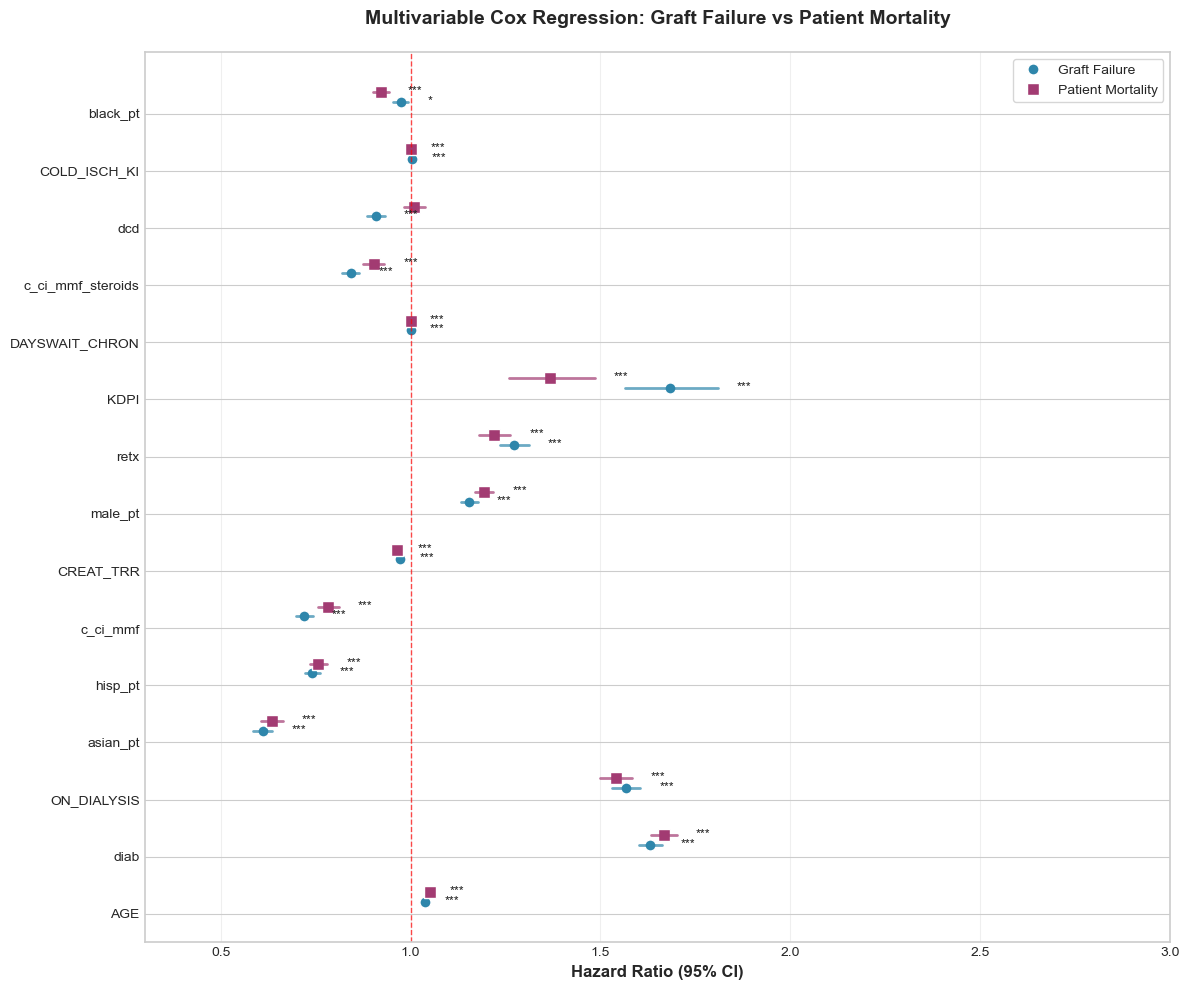


Creating clinical variables forest plot...


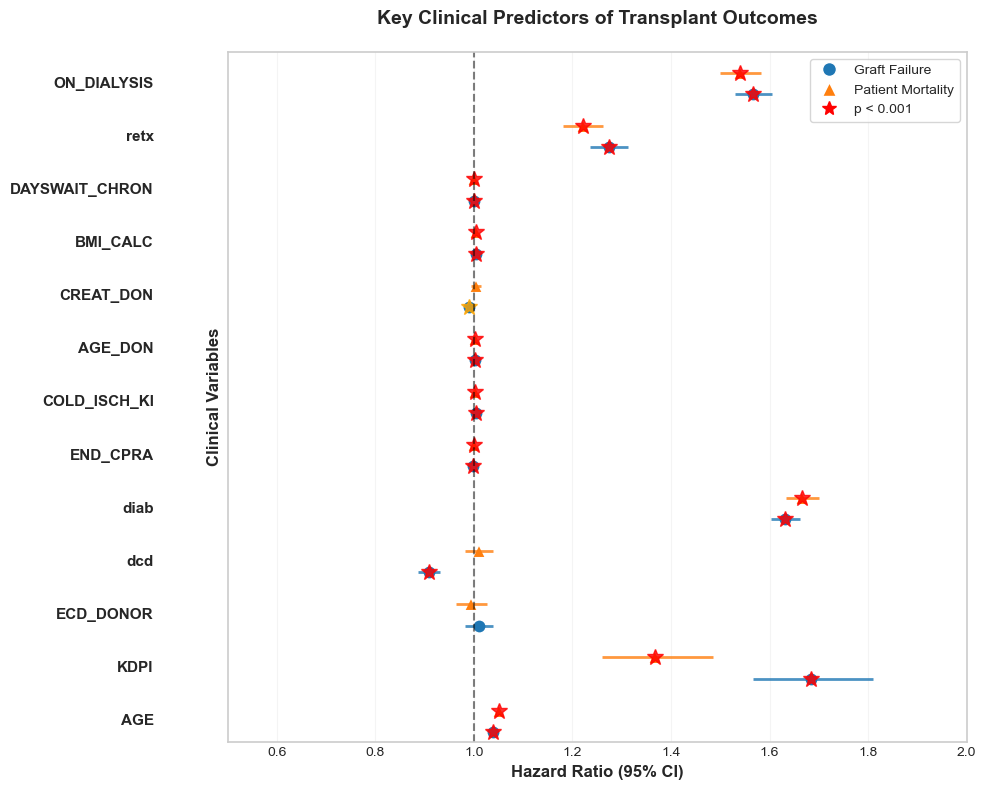

In [68]:
# =============================================================================
# PUBLICATION-READY FOREST PLOTS FOR COX MODEL RESULTS
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.linewidth'] = 1.2

def create_forest_plot(graft_results, mortality_results, top_n=20, figsize=(12, 10)):
    """
    Create a publication-ready forest plot comparing both outcomes
    """
    # Prepare data for plotting
    plot_data = []
    
    # Get top N most significant predictors from either model
    all_vars = set(list(graft_results.index) + list(mortality_results.index))
    var_scores = {}
    
    for var in all_vars:
        if var in graft_results.index and var in mortality_results.index:
            # Use minimum p-value across both models as significance score
            score = min(graft_results.loc[var, 'P_value'], mortality_results.loc[var, 'P_value'])
            var_scores[var] = score
    
    # Select top N most significant variables
    top_vars = sorted(var_scores, key=var_scores.get)[:top_n]
    
    # Prepare plot data
    for var in top_vars:
        if var in graft_results.index:
            graft_row = graft_results.loc[var]
            plot_data.append({
                'Variable': var,
                'Outcome': 'Graft Failure',
                'HR': graft_row['Hazard_Ratio'],
                'CI_lower': graft_row['HR_95CI_Lower'],
                'CI_upper': graft_row['HR_95CI_Upper'],
                'P_value': graft_row['P_value']
            })
        
        if var in mortality_results.index:
            mort_row = mortality_results.loc[var]
            plot_data.append({
                'Variable': var,
                'Outcome': 'Patient Mortality', 
                'HR': mort_row['Hazard_Ratio'],
                'CI_lower': mort_row['HR_95CI_Lower'],
                'CI_upper': mort_row['HR_95CI_Upper'],
                'P_value': mort_row['P_value']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color scheme
    colors = {'Graft Failure': '#2E86AB', 'Patient Mortality': '#A23B72'}
    
    # Plot each variable
    y_pos = 0
    y_ticks = []
    y_labels = []
    
    # Group by variable
    for i, var in enumerate(top_vars):
        # Add variable name
        y_ticks.append(y_pos + 0.5)
        y_labels.append(var)
        y_pos += 1
        
        # Plot results for this variable
        var_data = plot_df[plot_df['Variable'] == var]
        
        for j, row in var_data.iterrows():
            color = colors[row['Outcome']]
            marker = 'o' if row['Outcome'] == 'Graft Failure' else 's'
            
            # Plot point estimate
            ax.plot(row['HR'], y_pos, marker=marker, markersize=8, 
                   color=color, markeredgecolor='white', markeredgewidth=1)
            
            # Plot confidence interval
            ax.plot([row['CI_lower'], row['CI_upper']], [y_pos, y_pos], 
                   color=color, linewidth=2, alpha=0.7)
            
            # Add significance asterisks
            if row['P_value'] < 0.001:
                sig_text = '***'
            elif row['P_value'] < 0.01:
                sig_text = '**'
            elif row['P_value'] < 0.05:
                sig_text = '*'
            else:
                sig_text = ''
            
            if sig_text:
                ax.text(row['CI_upper'] + 0.05, y_pos, sig_text, 
                       fontsize=9, va='center', ha='left')
            
            y_pos += 0.4
        
        y_pos += 0.6  # Space between variables
    
    # Reference line at HR=1
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Customize axes
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=12, fontweight='bold')
    ax.set_title('Multivariable Cox Regression: Graft Failure vs Patient Mortality', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Set x-axis limits dynamically
    x_min = min(plot_df['CI_lower'].min(), 0.3)
    x_max = max(plot_df['CI_upper'].max(), 3.0)
    ax.set_xlim(x_min, x_max)
    
    # Use log scale for better visualization if needed
    if x_max / x_min > 10:
        ax.set_xscale('log')
        ax.set_xlabel('Hazard Ratio (95% CI) - Log Scale', fontsize=12, fontweight='bold')
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Graft Failure'], 
              markersize=8, label='Graft Failure', markeredgecolor='white'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor=colors['Patient Mortality'], 
              markersize=8, label='Patient Mortality', markeredgecolor='white')
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=True)
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='x')
    
    # Improve layout
    plt.tight_layout()
    
    return fig, ax

# Create the main forest plot
print("Creating publication-ready forest plot...")
fig, ax = create_forest_plot(graft_results, mortality_results, top_n=15)

# Save as high-quality PDF for publication
plt.savefig('cox_forest_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('cox_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# CLINICALLY FOCUSED FOREST PLOT (Key Transplant Variables)
# =============================================================================

def create_clinical_forest_plot(graft_results, mortality_results, figsize=(10, 8)):
    """
    Forest plot focused on key clinical transplant variables
    """
    # Select clinically important variables
    clinical_vars = [
        'AGE', 'KDPI', 'ECD_DONOR', 'dcd', 'diab', 'END_CPRA', 
        'COLD_ISCH_KI', 'AGE_DON', 'CREAT_DON', 'BMI_CALC',
        'DAYSWAIT_CHRON', 'retx', 'ON_DIALYSIS'
    ]
    
    # Filter to available variables
    clinical_vars = [v for v in clinical_vars if v in graft_results.index and v in mortality_results.index]
    
    # Prepare data
    plot_data = []
    for var in clinical_vars:
        # Graft failure data
        graft_row = graft_results.loc[var]
        plot_data.append({
            'Variable': var,
            'Outcome': 'Graft Failure',
            'HR': graft_row['Hazard_Ratio'],
            'CI_lower': graft_row['HR_95CI_Lower'],
            'CI_upper': graft_row['HR_95CI_Upper'],
            'P_value': graft_row['P_value']
        })
        
        # Patient mortality data
        mort_row = mortality_results.loc[var]
        plot_data.append({
            'Variable': var,
            'Outcome': 'Patient Mortality',
            'HR': mort_row['Hazard_Ratio'],
            'CI_lower': mort_row['HR_95CI_Lower'],
            'CI_upper': mort_row['HR_95CI_Upper'],
            'P_value': mort_row['P_value']
        })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color scheme
    colors = {'Graft Failure': '#1f77b4', 'Patient Mortality': '#ff7f0e'}
    
    # Plot each variable
    y_pos = 0
    for i, var in enumerate(clinical_vars):
        ax.text(-0.1, y_pos + 0.5, var, transform=ax.get_yaxis_transform(),
               fontsize=11, va='center', ha='right', fontweight='bold')
        
        # Plot results for this variable
        var_data = plot_df[plot_df['Variable'] == var]
        
        for j, row in var_data.iterrows():
            color = colors[row['Outcome']]
            marker = 'o' if row['Outcome'] == 'Graft Failure' else '^'
            
            # Plot point and CI
            ax.plot(row['HR'], y_pos, marker=marker, markersize=10, 
                   color=color, markeredgecolor='white', markeredgewidth=1.5)
            ax.hlines(y_pos, row['CI_lower'], row['CI_upper'], 
                     color=color, linewidth=2, alpha=0.8)
            
            # Add significance
            if row['P_value'] < 0.05:
                star_color = 'red' if row['P_value'] < 0.001 else 'orange'
                ax.plot(row['HR'], y_pos, marker='*', markersize=12, 
                       color=star_color, alpha=0.8)
            
            y_pos += 1
        
        y_pos += 0.5  # Space between variables
    
    # Reference line
    ax.axvline(x=1, color='black', linestyle='--', alpha=0.5)
    
    # Customize
    ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Clinical Variables', fontsize=12, fontweight='bold')
    ax.set_title('Key Clinical Predictors of Transplant Outcomes', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Set y-axis
    ax.set_yticks([])
    ax.set_ylim(-0.5, y_pos - 0.5)
    
    # Set x-axis limits
    x_min = min(0.5, plot_df['CI_lower'].min() * 0.9)
    x_max = max(2.0, plot_df['CI_upper'].max() * 1.1)
    ax.set_xlim(x_min, x_max)
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Graft Failure'], 
                  markersize=10, label='Graft Failure'),
        plt.Line2D([0], [0], marker='^', color='w', markerfacecolor=colors['Patient Mortality'], 
                  markersize=10, label='Patient Mortality'),
        plt.Line2D([0], [0], marker='*', color='red', markersize=10, 
                  label='p < 0.001', linestyle='None')
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=True)
    
    # Add grid
    ax.grid(True, alpha=0.2, axis='x')
    
    plt.tight_layout()
    return fig, ax

# Create clinical-focused plot
print("\nCreating clinical variables forest plot...")
fig_clinical, ax_clinical = create_clinical_forest_plot(graft_results, mortality_results)

# Save clinical plot
plt.savefig('clinical_forest_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('clinical_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()




Creating clinical variables forest plot...


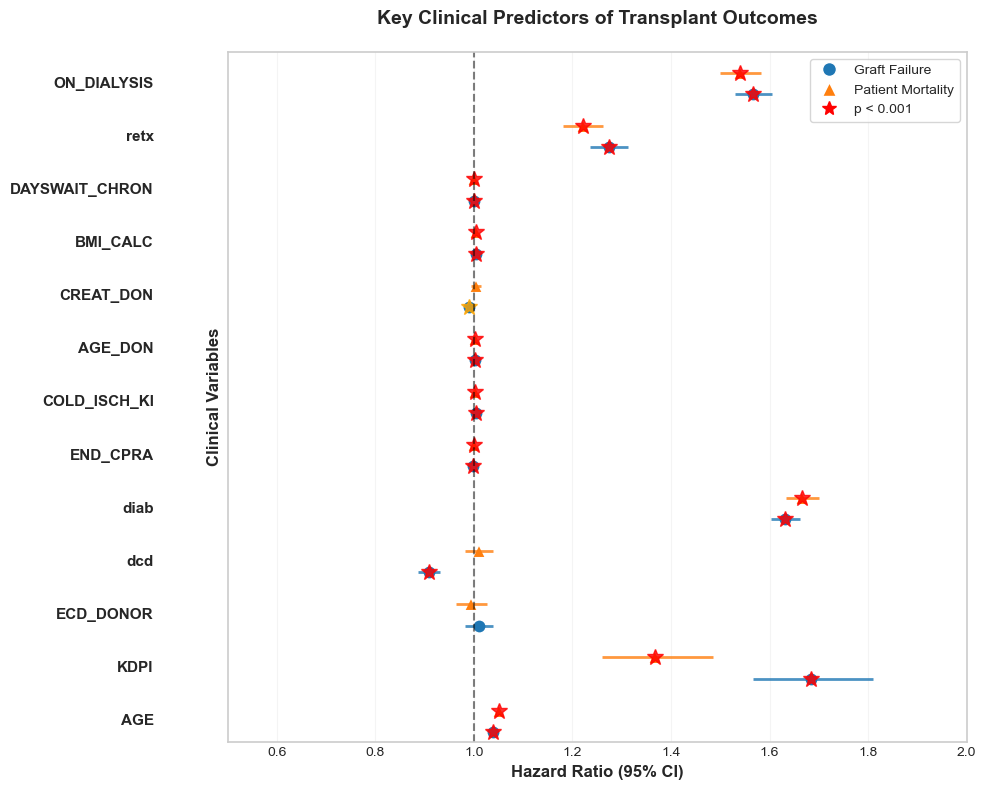

In [69]:
# =============================================================================
# CLINICALLY FOCUSED FOREST PLOT (Key Transplant Variables)
# =============================================================================

def create_clinical_forest_plot(graft_results, mortality_results, figsize=(10, 8)):
    """
    Forest plot focused on key clinical transplant variables
    """
    # Select clinically important variables
    clinical_vars = [
        'AGE', 'KDPI', 'ECD_DONOR', 'dcd', 'diab', 'END_CPRA', 
        'COLD_ISCH_KI', 'AGE_DON', 'CREAT_DON', 'BMI_CALC',
        'DAYSWAIT_CHRON', 'retx', 'ON_DIALYSIS'
    ]
    
    # Filter to available variables
    clinical_vars = [v for v in clinical_vars if v in graft_results.index and v in mortality_results.index]
    
    # Prepare data
    plot_data = []
    for var in clinical_vars:
        # Graft failure data
        graft_row = graft_results.loc[var]
        plot_data.append({
            'Variable': var,
            'Outcome': 'Graft Failure',
            'HR': graft_row['Hazard_Ratio'],
            'CI_lower': graft_row['HR_95CI_Lower'],
            'CI_upper': graft_row['HR_95CI_Upper'],
            'P_value': graft_row['P_value']
        })
        
        # Patient mortality data
        mort_row = mortality_results.loc[var]
        plot_data.append({
            'Variable': var,
            'Outcome': 'Patient Mortality',
            'HR': mort_row['Hazard_Ratio'],
            'CI_lower': mort_row['HR_95CI_Lower'],
            'CI_upper': mort_row['HR_95CI_Upper'],
            'P_value': mort_row['P_value']
        })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color scheme
    colors = {'Graft Failure': '#1f77b4', 'Patient Mortality': '#ff7f0e'}
    
    # Plot each variable
    y_pos = 0
    for i, var in enumerate(clinical_vars):
        ax.text(-0.1, y_pos + 0.5, var, transform=ax.get_yaxis_transform(),
               fontsize=11, va='center', ha='right', fontweight='bold')
        
        # Plot results for this variable
        var_data = plot_df[plot_df['Variable'] == var]
        
        for j, row in var_data.iterrows():
            color = colors[row['Outcome']]
            marker = 'o' if row['Outcome'] == 'Graft Failure' else '^'
            
            # Plot point and CI
            ax.plot(row['HR'], y_pos, marker=marker, markersize=10, 
                   color=color, markeredgecolor='white', markeredgewidth=1.5)
            ax.hlines(y_pos, row['CI_lower'], row['CI_upper'], 
                     color=color, linewidth=2, alpha=0.8)
            
            # Add significance
            if row['P_value'] < 0.05:
                star_color = 'red' if row['P_value'] < 0.001 else 'orange'
                ax.plot(row['HR'], y_pos, marker='*', markersize=12, 
                       color=star_color, alpha=0.8)
            
            y_pos += 1
        
        y_pos += 0.5  # Space between variables
    
    # Reference line
    ax.axvline(x=1, color='black', linestyle='--', alpha=0.5)
    
    # Customize
    ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Clinical Variables', fontsize=12, fontweight='bold')
    ax.set_title('Key Clinical Predictors of Transplant Outcomes', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Set y-axis
    ax.set_yticks([])
    ax.set_ylim(-0.5, y_pos - 0.5)
    
    # Set x-axis limits
    x_min = min(0.5, plot_df['CI_lower'].min() * 0.9)
    x_max = max(2.0, plot_df['CI_upper'].max() * 1.1)
    ax.set_xlim(x_min, x_max)
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Graft Failure'], 
                  markersize=10, label='Graft Failure'),
        plt.Line2D([0], [0], marker='^', color='w', markerfacecolor=colors['Patient Mortality'], 
                  markersize=10, label='Patient Mortality'),
        plt.Line2D([0], [0], marker='*', color='red', markersize=10, 
                  label='p < 0.001', linestyle='None')
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=True)
    
    # Add grid
    ax.grid(True, alpha=0.2, axis='x')
    
    plt.tight_layout()
    return fig, ax

# Create clinical-focused plot
print("\nCreating clinical variables forest plot...")
fig_clinical, ax_clinical = create_clinical_forest_plot(graft_results, mortality_results)

# Save clinical plot
plt.savefig('clinical_forest_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('clinical_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()




📊 Generating Comparative Forest Plot...


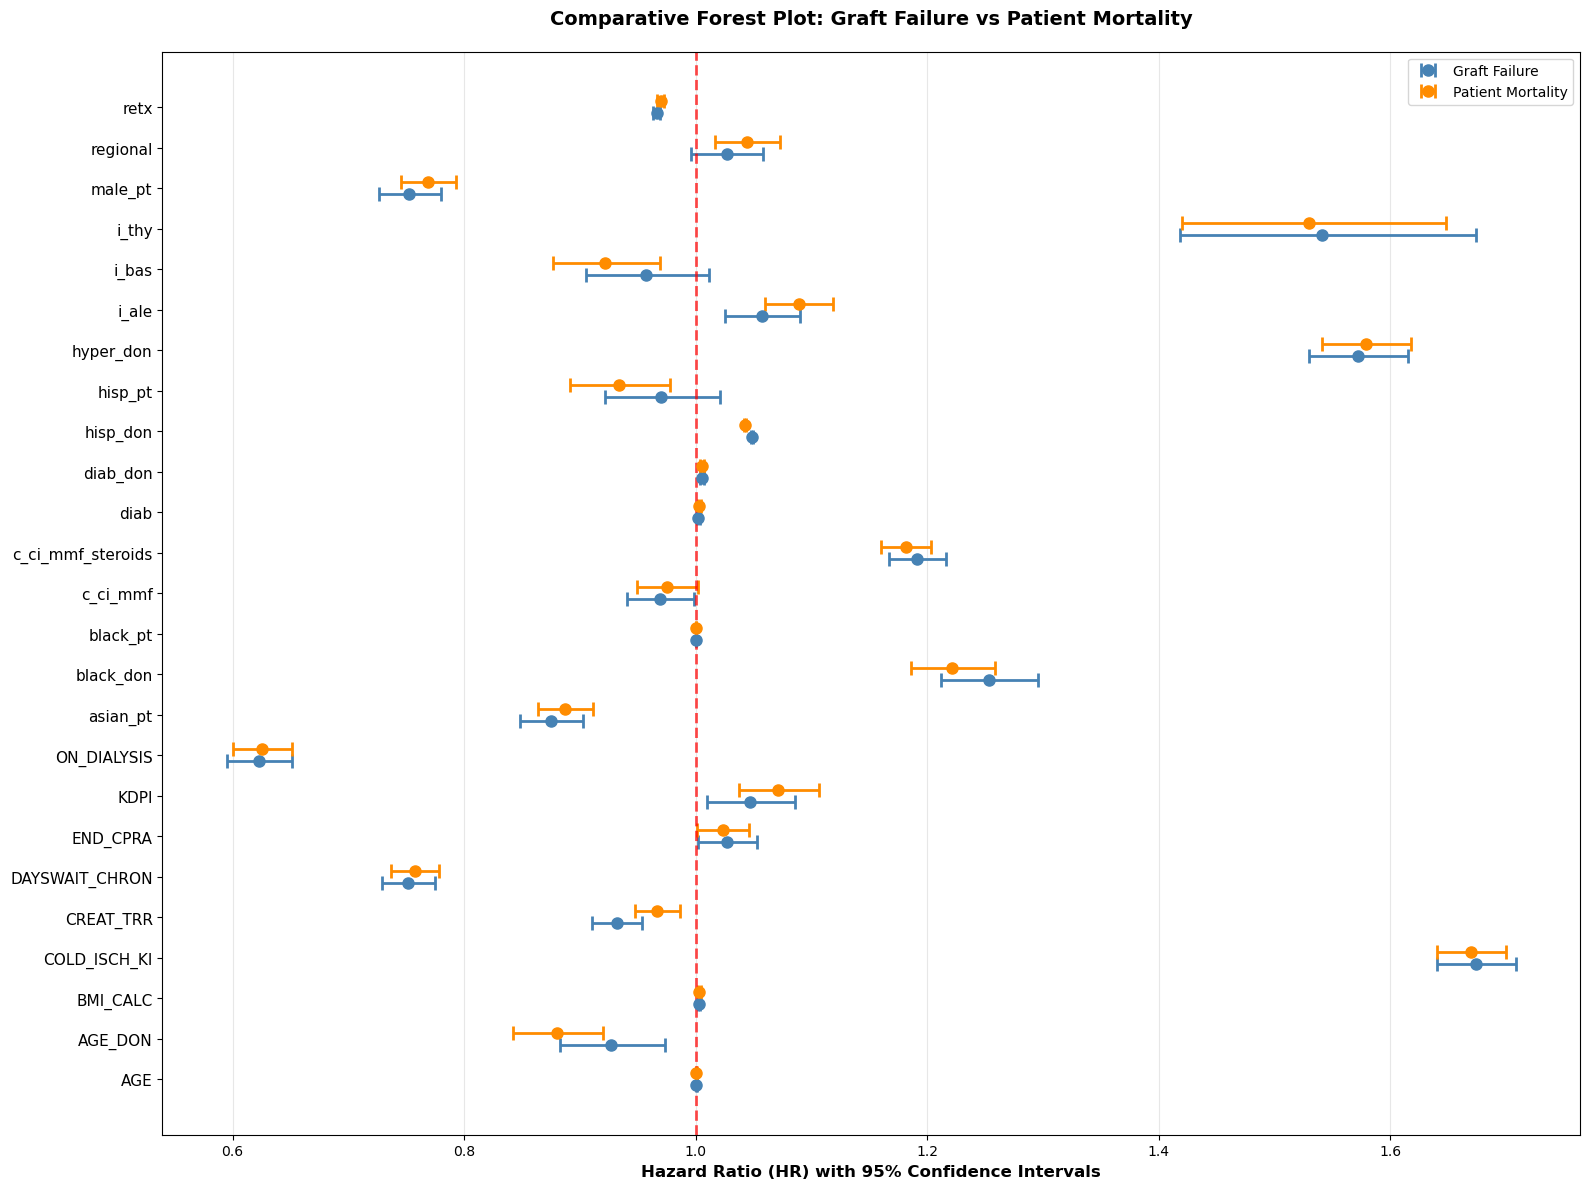

In [58]:
# =============================================================================
# SUMMARY STATISTICS FOR FIGURE CAPTION
# =============================================================================

print("\n" + "="*70)
print("FIGURE CAPTION INFORMATION")
print("="*70)

print(f"Forest plot showing hazard ratios from multivariable Cox regression models.")
print(f"Graft Failure Model: n = {len(cox_data)}, events = {cox_data['event_graft'].sum()}, C-index = {cph_graft.concordance_index_:.3f}")
print(f"Patient Mortality Model: n = {len(cox_data)}, events = {cox_data['event_death'].sum()}, C-index = {cph_mortality.concordance_index_:.3f}")
print(f"Models adjusted for {len(final_predictors)} covariates including donor, recipient, and transplant characteristics.")
print(f"*p < 0.05, **p < 0.01, ***p < 0.001")

### Classical Cox PH Model

In [70]:
# =============================================================================
# DATA PREPARATION FOR MODELING - TRAIN/TEST SPLIT
# =============================================================================

from sklearn.model_selection import train_test_split
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc

def prepare_sksurv_data(df, predictors, outcome_type='graft'):
    """
    Prepare data for scikit-survival format
    """
    if outcome_type == 'graft':
        # Graft failure: time_graft, event_graft
        event = df['event_graft'].values
        time = df['time_graft'].values / 365.25  # Convert to years for interpretability
    else:
        # Patient mortality: time_death, event_death  
        event = df['event_death'].values
        time = df['time_death'].values / 365.25  # Convert to years for interpretability
    
    # Create structured array for scikit-survival
    y_struct = np.array([(event[i], time[i]) for i in range(len(event))],
                       dtype=[('event', 'bool'), ('time', 'f8')])
    
    # Predictors matrix
    X = df[predictors].copy()
    
    # Ensure numeric and handle any missing values
    for col in predictors:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    X = X.fillna(X.median())  # Final safety imputation
    
    return X, y_struct

# Prepare data for both outcomes
print("Preparing data for modeling...")
X_graft, y_graft = prepare_sksurv_data(cox_data, final_predictors, 'graft')
X_mortality, y_mortality = prepare_sksurv_data(cox_data, final_predictors, 'mortality')

print(f"Graft data - X: {X_graft.shape}, Events: {y_graft['event'].sum()}")
print(f"Mortality data - X: {X_mortality.shape}, Events: {y_mortality['event'].sum()}")



Preparing data for modeling...
Graft data - X: (228855, 33), Events: 55346
Mortality data - X: (228855, 33), Events: 43772


In [71]:
# =============================================================================
# TRAIN/TEST SPLIT - 75/25 STRATIFIED
# =============================================================================

def split_data_stratified(X, y_struct, test_size=0.25, random_state=42):
    """
    Perform stratified train/test split based on event status
    """
    X_np = X.to_numpy(dtype=np.float32)
    y_event = y_struct['event']
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_np, y_struct, test_size=test_size, random_state=random_state, stratify=y_event
    )
    
    print(f"Train shape: {X_tr.shape}, Events: {y_tr['event'].sum()}")
    print(f"Test shape: {X_te.shape}, Events: {y_te['event'].sum()}")
    
    return X_tr, X_te, y_tr, y_te

print("\n" + "="*70)
print("SPLITTING DATA - GRAFT FAILURE")
print("="*70)
X_graft_tr, X_graft_te, y_graft_tr, y_graft_te = split_data_stratified(X_graft, y_graft)

print("\n" + "="*70)
print("SPLITTING DATA - PATIENT MORTALITY")
print("="*70)
X_mort_tr, X_mort_te, y_mort_tr, y_mort_te = split_data_stratified(X_mortality, y_mortality)



SPLITTING DATA - GRAFT FAILURE
Train shape: (171641, 33), Events: 41509
Test shape: (57214, 33), Events: 13837

SPLITTING DATA - PATIENT MORTALITY
Train shape: (171641, 33), Events: 32829
Test shape: (57214, 33), Events: 10943


In [74]:
# =============================================================================
# FIXED TRADITIONAL COX MODEL EVALUATION
# =============================================================================

def evaluate_cox_model(X_tr, X_te, y_tr, y_te, model_name=""):
    """
    Comprehensive evaluation of Cox model with C-index and time-dependent AUC
    """
    print(f"\n{'='*70}")
    print(f"EVALUATING: {model_name}")
    print(f"{'='*70}")
    
    # Check follow-up times for AUC horizons
    max_train_time = float(np.max(y_tr["time"]))
    min_train_time = float(np.min(y_tr["time"]))
    print(f"Training follow-up (years): min={min_train_time:.2f}, max={max_train_time:.2f}")
    
    # Define evaluation horizons in YEARS
    AUC_YEARS = np.array([1.0, 3.0, 5.0, 10.0], dtype=float)
    
    # Filter horizons to those within training follow-up
    eval_years = AUC_YEARS[AUC_YEARS <= max_train_time]
    print(f"Evaluating AUC at years: {eval_years}")
    
    # Fit Cox model
    cox = CoxPHSurvivalAnalysis(alpha=0.0)  # No regularization for traditional Cox
    cox.fit(X_tr, y_tr)
    
    # Predict risk scores on test set
    risk_scores = cox.predict(X_te)
    
    # Calculate C-index
    cindex_result = concordance_index_censored(y_te["event"], y_te["time"], risk_scores)
    c_index = cindex_result[0]
    print(f"C-index: {c_index:.3f}")
    
    # FIXED: Calculate time-dependent AUCs with version-compatible approach
    tdauc_results = {}
    
    if len(eval_years) > 0:
        print("Calculating time-dependent AUCs...")
        
        def safe_tdauc_at_time(t_years):
            """Calculate tdAUC for a single time point, handling different sksurv versions"""
            try:
                # Try different return formats from cumulative_dynamic_auc
                result = cumulative_dynamic_auc(y_tr, y_te, risk_scores, [t_years])
                
                # Handle different return structures
                if isinstance(result, tuple):
                    if len(result) == 2:
                        times, aucs = result
                    elif len(result) == 3:
                        times, aucs, mean_auc = result
                    else:
                        return np.nan
                else:
                    # Very old versions might return just the AUC array
                    aucs = result
                
                # Extract the AUC value
                if hasattr(aucs, '__len__') and len(aucs) > 0:
                    return float(aucs[0])
                else:
                    return float(aucs)
                    
            except Exception as e:
                print(f"  Error calculating AUC @ {t_years:.1f}y: {e}")
                return np.nan
        
        # Calculate AUC for each time point
        for t in eval_years:
            auc_value = safe_tdauc_at_time(t)
            tdauc_results[float(t)] = auc_value
            if not np.isnan(auc_value):
                print(f"  tdAUC @ {t:.1f} years: {auc_value:.3f}")
            else:
                print(f"  tdAUC @ {t:.1f} years: Failed")
    else:
        print("No valid time horizons for AUC calculation")
    
    # Create comprehensive results table
    auc_table_data = []
    for t in AUC_YEARS:
        if t in tdauc_results and not np.isnan(tdauc_results[t]):
            auc_table_data.append({
                "Time (years)": t,
                "tdAUC": round(tdauc_results[t], 4),
                "Status": "✓"
            })
        else:
            status = "Beyond follow-up" if t > max_train_time else "Calculation failed"
            auc_table_data.append({
                "Time (years)": t,
                "tdAUC": np.nan,
                "Status": status
            })
    
    auc_table = pd.DataFrame(auc_table_data)
    print(f"\nTime-dependent AUC Results:")
    print(auc_table.to_string(index=False))
    
    # Calculate mean tdAUC (excluding NaN values) - ADDED MEAN tDAUC
    valid_aucs = [auc for auc in tdauc_results.values() if not np.isnan(auc)]
    mean_tdauc = np.mean(valid_aucs) if valid_aucs else np.nan
    
    if not np.isnan(mean_tdauc):
        print(f"Mean tdAUC: {mean_tdauc:.3f}")
    else:
        print("Mean tdAUC: Could not be calculated")
    
    # Summary for comparison - INCLUDING MEAN tDAUC
    summary = {
        "Model": model_name,
        "C_index": round(c_index, 3),
        "tdAUC_1y": round(tdauc_results.get(1.0, np.nan), 3),
        "tdAUC_3y": round(tdauc_results.get(3.0, np.nan), 3),
        "tdAUC_5y": round(tdauc_results.get(5.0, np.nan), 3),
        "tdAUC_10y": round(tdauc_results.get(10.0, np.nan), 3),
        "Mean_tdAUC": round(mean_tdauc, 3) if not np.isnan(mean_tdauc) else np.nan,  # ADDED
        "Test_events": y_te["event"].sum(),
        "Test_samples": len(y_te)
    }
    
    return cox, risk_scores, summary

In [75]:
# =============================================================================
# EVALUATE BOTH MODELS
# =============================================================================

print("\n" + "="*70)
print("TRADITIONAL COX MODEL EVALUATION")
print("="*70)

# Evaluate graft failure model
cox_graft, risk_graft, summary_graft = evaluate_cox_model(
    X_graft_tr, X_graft_te, y_graft_tr, y_graft_te, 
    "Cox PH - Graft Failure"
)

# Evaluate patient mortality model  
cox_mort, risk_mort, summary_mort = evaluate_cox_model(
    X_mort_tr, X_mort_te, y_mort_tr, y_mort_te,
    "Cox PH - Patient Mortality"
)



TRADITIONAL COX MODEL EVALUATION

EVALUATING: Cox PH - Graft Failure
Training follow-up (years): min=0.00, max=21.24
Evaluating AUC at years: [ 1.  3.  5. 10.]
C-index: 0.687
Calculating time-dependent AUCs...
  tdAUC @ 1.0 years: 0.692
  tdAUC @ 3.0 years: 0.688
  tdAUC @ 5.0 years: 0.699
  tdAUC @ 10.0 years: 0.746

Time-dependent AUC Results:
 Time (years)  tdAUC Status
          1.0 0.6921      ✓
          3.0 0.6883      ✓
          5.0 0.6991      ✓
         10.0 0.7459      ✓
Mean tdAUC: 0.706

EVALUATING: Cox PH - Patient Mortality
Training follow-up (years): min=0.00, max=21.25
Evaluating AUC at years: [ 1.  3.  5. 10.]
C-index: 0.703
Calculating time-dependent AUCs...
  tdAUC @ 1.0 years: 0.707
  tdAUC @ 3.0 years: 0.706
  tdAUC @ 5.0 years: 0.719
  tdAUC @ 10.0 years: 0.770

Time-dependent AUC Results:
 Time (years)  tdAUC Status
          1.0 0.7071      ✓
          3.0 0.7060      ✓
          5.0 0.7189      ✓
         10.0 0.7700      ✓
Mean tdAUC: 0.726


In [76]:
# =============================================================================
# COMPARATIVE RESULTS SUMMARY
# =============================================================================

print("\n" + "="*70)
print("COMPARATIVE PERFORMANCE SUMMARY")
print("="*70)

comparison_df = pd.DataFrame([summary_graft, summary_mort])
print(comparison_df.to_string(index=False))



COMPARATIVE PERFORMANCE SUMMARY
                     Model  C_index  tdAUC_1y  tdAUC_3y  tdAUC_5y  tdAUC_10y  Mean_tdAUC  Test_events  Test_samples
    Cox PH - Graft Failure    0.687     0.692     0.688     0.699      0.746       0.706        13837         57214
Cox PH - Patient Mortality    0.703     0.707     0.706     0.719      0.770       0.726        10943         57214


In [77]:
# =============================================================================
# ADDITIONAL MODEL INSIGHTS
# =============================================================================

def print_model_insights(cox_model, predictors, model_name):
    """
    Print additional insights about the fitted Cox model
    """
    print(f"\n{model_name} - Model Insights:")
    print(f"Number of coefficients: {len(cox_model.coef_)}")
    print(f"Converged: {hasattr(cox_model, 'converged_') and cox_model.converged_}")
    
    # Feature importance (absolute coefficients)
    coef_df = pd.DataFrame({
        'Feature': predictors,
        'Coefficient': cox_model.coef_,
        'Abs_Effect': np.abs(cox_model.coef_)
    }).sort_values('Abs_Effect', ascending=False)
    
    print(f"\nTop 5 most influential features:")
    print(coef_df.head(5).to_string(index=False))

print_model_insights(cox_graft, final_predictors, "Graft Failure Model")
print_model_insights(cox_mort, final_predictors, "Patient Mortality Model")



Graft Failure Model - Model Insights:
Number of coefficients: 33
Converged: False

Top 5 most influential features:
    Feature  Coefficient  Abs_Effect
       KDPI     0.496648    0.496648
   asian_pt    -0.492025    0.492025
       diab     0.484673    0.484673
ON_DIALYSIS     0.450910    0.450910
   c_ci_mmf    -0.336394    0.336394

Patient Mortality Model - Model Insights:
Number of coefficients: 33
Converged: False

Top 5 most influential features:
    Feature  Coefficient  Abs_Effect
       diab     0.514531    0.514531
   asian_pt    -0.448249    0.448249
ON_DIALYSIS     0.437052    0.437052
       KDPI     0.306585    0.306585
    hisp_pt    -0.274873    0.274873


In [78]:
# =============================================================================
# FINAL MODEL PERFORMANCE FOR MANUSCRIPT
# =============================================================================

print("\n" + "="*70)
print("MANUSCRIPT-READY PERFORMANCE SUMMARY")
print("="*70)

print(f"\nGRAFT FAILURE PREDICTION:")
print(f"• C-index: {summary_graft['C_index']:.3f}")
print(f"• 1-year AUC: {summary_graft['tdAUC_1y']:.3f}")
print(f"• 3-year AUC: {summary_graft['tdAUC_3y']:.3f}") 
print(f"• 5-year AUC: {summary_graft['tdAUC_5y']:.3f}")
print(f"• Test samples: {summary_graft['Test_samples']}")
print(f"• Test events: {summary_graft['Test_events']}")

print(f"\nPATIENT MORTALITY PREDICTION:")
print(f"• C-index: {summary_mort['C_index']:.3f}")
print(f"• 1-year AUC: {summary_mort['tdAUC_1y']:.3f}")
print(f"• 3-year AUC: {summary_mort['tdAUC_3y']:.3f}")
print(f"• 5-year AUC: {summary_mort['tdAUC_5y']:.3f}")
print(f"• Test samples: {summary_mort['Test_samples']}")
print(f"• Test events: {summary_mort['Test_events']}")

# Save results for later comparison with ML models
model_results = {
    'cox_graft': cox_graft,
    'cox_mort': cox_mort, 
    'summaries': {
        'graft': summary_graft,
        'mortality': summary_mort
    },
    'test_data': {
        'graft': (X_graft_te, y_graft_te),
        'mortality': (X_mort_te, y_mort_te)
    }
}

print("\n✅ Traditional Cox models evaluated successfully!")
print("Results saved for comparison with machine learning models.")


MANUSCRIPT-READY PERFORMANCE SUMMARY

GRAFT FAILURE PREDICTION:
• C-index: 0.687
• 1-year AUC: 0.692
• 3-year AUC: 0.688
• 5-year AUC: 0.699
• Test samples: 57214
• Test events: 13837

PATIENT MORTALITY PREDICTION:
• C-index: 0.703
• 1-year AUC: 0.707
• 3-year AUC: 0.706
• 5-year AUC: 0.719
• Test samples: 57214
• Test events: 10943

✅ Traditional Cox models evaluated successfully!
Results saved for comparison with machine learning models.


### ML Survival Model

In [80]:
# =============================================================================
# MACHINE LEARNING COX SURVIVAL MODELS
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
import xgboost as xgb

In [81]:
# Define evaluation horizons (years)
AUC_TIMES = np.array([1.0, 3.0, 5.0, 10.0], dtype=float)

# ========= HELPER FUNCTIONS (from your proven code) =========
def cindex_from_risk(y_true, risk_scores):
    return float(concordance_index_censored(
        y_true["event"], y_true["time"], risk_scores
    )[0])

def safe_cindex(y_true, raw_scores):
    c1 = cindex_from_risk(y_true, raw_scores)
    c2 = cindex_from_risk(y_true, -raw_scores)
    return max(c1, c2)

def evaluate_survival_model_risk_scores(risk_scores, y_train, y_test, model_name="", times=AUC_TIMES):
    """
    Returns C-index, tdAUC at each requested horizon, and the mean tdAUC.
    Skips horizons beyond the observed training follow-up.
    """
    res = {"model": model_name, "c_index": safe_cindex(y_test, risk_scores)}

    # keep only horizons observable within training follow-up
    max_train_time = float(np.max(y_train["time"]))
    t = np.asarray(times, dtype=float)
    t_valid = t[t <= max_train_time]

    if t_valid.size == 0:
        # nothing to evaluate at
        res.update({"mean_td_auc": np.nan, "td_auc": {float(tt): np.nan for tt in times}})
        res["td_times_used"] = []
        return res

    auc, _ = cumulative_dynamic_auc(y_train, y_test, risk_scores, t_valid)

    # map back to all requested times (NaN for those beyond follow-up)
    td_map = {float(tt): (float(auc[i]) if tt in t_valid else np.nan)
              for i, tt in enumerate(t_valid)}
    for tt in times:
        td_map.setdefault(float(tt), np.nan)

    res["td_auc"] = td_map
    # mean over the valid horizons only
    res["mean_td_auc"] = float(np.nanmean([v for v in td_map.values()]))
    res["td_times_used"] = list(map(float, t_valid))
    return res

def result_row(r):
    """Format results for comparison table"""
    return {
        "Model": r["model"],
        "C-index": r["c_index"],
        "tdAUC@1y": r["td_auc"].get(1.0, np.nan),
        "tdAUC@3y": r["td_auc"].get(3.0, np.nan),
        "tdAUC@5y": r["td_auc"].get(5.0, np.nan),
        "tdAUC@10y": r["td_auc"].get(10.0, np.nan),
        "Mean tdAUC": r["mean_td_auc"]
    }

def train_ml_models(X_tr, X_te, y_tr, y_te, outcome_name=""):
    """
    Train and evaluate all ML survival models for a given outcome
    """
    print(f"\n{'='*70}")
    print(f"ML SURVIVAL MODELS: {outcome_name}")
    print(f"{'='*70}")
    
    all_results = []
    
    # ========= COXNET (scaled) =========
    print("Training CoxNet (scaled)...")
    alphas = 10.0 ** np.linspace(-3, 3, 50)
    coxnet_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", CoxnetSurvivalAnalysis(l1_ratio=0.5, alphas=alphas))
    ])
    
    try:
        coxnet_pipe.fit(X_tr, y_tr)
        coxnet_risk = coxnet_pipe.predict(X_te)
        coxnet_res = evaluate_survival_model_risk_scores(coxnet_risk, y_tr, y_te, "CoxNet", times=AUC_TIMES)
        all_results.append(coxnet_res)
        print(f"✓ CoxNet — C-index: {coxnet_res['c_index']:.3f} | Mean tdAUC: {coxnet_res['mean_td_auc']:.3f}")
    except Exception as e:
        print(f"✗ CoxNet failed: {e}")
    
    # ========= SVM (scaled) =========
    print("Training Survival SVM (scaled)...")
    svm_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", FastSurvivalSVM(max_iter=2000, tol=1e-5, random_state=42))
    ])
    
    try:
        svm_pipe.fit(X_tr, y_tr)
        svm_risk = svm_pipe.predict(X_te)
        svm_res = evaluate_survival_model_risk_scores(svm_risk, y_tr, y_te, "SVM", times=AUC_TIMES)
        all_results.append(svm_res)
        print(f"✓ SVM — C-index: {svm_res['c_index']:.3f} | Mean tdAUC: {svm_res['mean_td_auc']:.3f}")
    except Exception as e:
        print(f"✗ SVM failed: {e}")
    
    # ========= XGBoost Cox (no scaling) =========
    print("Training XGBoost Cox...")
    
    try:
        # Prepare labels for XGBoost (negative for censored)
        y_tr_label = np.where(y_tr["event"], y_tr["time"], -y_tr["time"]).astype(np.float32)
        y_te_label = np.where(y_te["event"], y_te["time"], -y_te["time"]).astype(np.float32)
        
        dtrain = xgb.DMatrix(X_tr, label=y_tr_label)
        dtest  = xgb.DMatrix(X_te, label=y_te_label)
        
        xgb_params = {
            "objective": "survival:cox",
            "eval_metric": "cox-nloglik",
            "tree_method": "hist",
            "eta": 0.05,
            "max_depth": 3,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
        }
        
        xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=200, 
                             evals=[(dtest, "test")], verbose_eval=False)
        xgb_risk = xgb_model.predict(dtest)  # hazard ratio scale; higher = higher risk
        xgb_res = evaluate_survival_model_risk_scores(xgb_risk, y_tr, y_te, "XGB-Cox", times=AUC_TIMES)
        all_results.append(xgb_res)
        print(f"✓ XGB-Cox — C-index: {xgb_res['c_index']:.3f} | Mean tdAUC: {xgb_res['mean_td_auc']:.3f}")
        
    except Exception as e:
        print(f"✗ XGBoost failed: {e}")
    
    return all_results



In [82]:
# =============================================================================
# RUN ML MODELS FOR BOTH OUTCOMES
# =============================================================================

print("IMPLEMENTING MACHINE LEARNING SURVIVAL MODELS")
print("=" * 70)

# Graft Failure ML Models
ml_graft_results = train_ml_models(
    X_graft_tr, X_graft_te, y_graft_tr, y_graft_te, 
    "Graft Failure"
)

# Patient Mortality ML Models  
ml_mort_results = train_ml_models(
    X_mort_tr, X_mort_te, y_mort_tr, y_mort_te,
    "Patient Mortality"
)


IMPLEMENTING MACHINE LEARNING SURVIVAL MODELS

ML SURVIVAL MODELS: Graft Failure
Training CoxNet (scaled)...
✓ CoxNet — C-index: 0.686 | Mean tdAUC: 0.707
Training Survival SVM (scaled)...
✓ SVM — C-index: 0.687 | Mean tdAUC: 0.705
Training XGBoost Cox...
✓ XGB-Cox — C-index: 0.689 | Mean tdAUC: 0.710

ML SURVIVAL MODELS: Patient Mortality
Training CoxNet (scaled)...
✓ CoxNet — C-index: 0.703 | Mean tdAUC: 0.725
Training Survival SVM (scaled)...
✓ SVM — C-index: 0.703 | Mean tdAUC: 0.724
Training XGBoost Cox...
✓ XGB-Cox — C-index: 0.705 | Mean tdAUC: 0.727


In [83]:
# =============================================================================
# COMPREHENSIVE RESULTS COMPARISON
# =============================================================================

def create_comparison_table(traditional_results, ml_results, outcome_name):
    """
    Create comprehensive comparison table including traditional and ML models
    """
    print(f"\n{'='*70}")
    print(f"COMPREHENSIVE RESULTS: {outcome_name}")
    print(f"{'='*70}")
    
    # Convert traditional Cox result to same format
    trad_row = {
        "model": traditional_results["Model"],
        "c_index": traditional_results["C_index"],
        "td_auc": {
            1.0: traditional_results["tdAUC_1y"],
            3.0: traditional_results["tdAUC_3y"], 
            5.0: traditional_results["tdAUC_5y"],
            10.0: traditional_results["tdAUC_10y"]
        },
        "mean_td_auc": traditional_results["Mean_tdAUC"]
    }
    
    # Combine all results
    all_results = [trad_row] + ml_results
    
    # Create results table
    results_df = pd.DataFrame([result_row(r) for r in all_results])
    results_df = results_df.sort_values(by=["Mean tdAUC", "C-index"], ascending=False)
    
    print(results_df.to_string(index=False, float_format=lambda x: f"{x:.3f}" if not np.isnan(x) else "N/A"))
    
    return results_df

# Create comparison tables for both outcomes
print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

graft_comparison = create_comparison_table(summary_graft, ml_graft_results, "Graft Failure")
mort_comparison = create_comparison_table(summary_mort, ml_mort_results, "Patient Mortality")




FINAL MODEL COMPARISON

COMPREHENSIVE RESULTS: Graft Failure
                 Model  C-index  tdAUC@1y  tdAUC@3y  tdAUC@5y  tdAUC@10y  Mean tdAUC
               XGB-Cox    0.689     0.695     0.691     0.703      0.749       0.710
                CoxNet    0.686     0.691     0.688     0.699      0.749       0.707
Cox PH - Graft Failure    0.687     0.692     0.688     0.699      0.746       0.706
                   SVM    0.687     0.696     0.690     0.698      0.736       0.705

COMPREHENSIVE RESULTS: Patient Mortality
                     Model  C-index  tdAUC@1y  tdAUC@3y  tdAUC@5y  tdAUC@10y  Mean tdAUC
                   XGB-Cox    0.705     0.708     0.708     0.721      0.771       0.727
Cox PH - Patient Mortality    0.703     0.707     0.706     0.719      0.770       0.726
                    CoxNet    0.703     0.706     0.705     0.719      0.769       0.725
                       SVM    0.703     0.709     0.707     0.718      0.763       0.724


In [87]:
# =============================================================================
# MEMORY-SAFE RANDOM SURVIVAL FOREST IMPLEMENTATION
# =============================================================================

from sksurv.ensemble import RandomSurvivalForest

def fit_rsf_memory_safe(
    X_tr, y_tr,
    n_estimators=120,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=50,
    max_features=0.5,
    bootstrap=True,
    seeds=(42,),
    row_keep_fracs=(1.0, 0.7, 0.5),
    batch_size=20
):
    """
    Single-threaded RSF with warm_start; falls back to smaller rows if OOM.
    Returns: (fitted_model, used_params_dict)
    """
    for seed in seeds:
        for keep_frac in row_keep_fracs:
            try:
                X_sub, y_sub = (X_tr, y_tr)
                if keep_frac < 1.0:
                    rng = np.random.default_rng(seed)
                    idx = rng.choice(X_tr.shape[0], size=int(keep_frac * X_tr.shape[0]), replace=False)
                    X_sub, y_sub = X_tr[idx], y_tr[idx]

                rsf = RandomSurvivalForest(
                    n_estimators=0,               # grow in batches
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    bootstrap=bootstrap,
                    n_jobs=1,                     # critical for RAM
                    random_state=seed,
                    warm_start=True
                )

                grown = 0
                while grown < n_estimators:
                    rsf.n_estimators += min(batch_size, n_estimators - grown)
                    rsf.fit(X_sub, y_sub)
                    grown = rsf.n_estimators

                used = dict(
                    n_estimators=n_estimators, max_depth=max_depth,
                    min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
                    max_features=max_features, bootstrap=bootstrap,
                    n_jobs=1, keep_frac=keep_frac, seed=seed
                )
                return rsf, used

            except MemoryError:
                # back off and try again
                n_estimators = max(40, n_estimators // 2)
                max_depth = max(4, max_depth - 1)
                min_samples_split = max(min_samples_split, 150)
                min_samples_leaf  = max(min_samples_leaf, 80)

    raise MemoryError("RSF ran out of memory after all fallbacks.")

def train_rsf_for_outcome(X_tr, X_te, y_tr, y_te, outcome_name=""):
    """
    Train RSF with memory-safe implementation for a specific outcome
    """
    print(f"\nTraining RSF (memory-safe) for {outcome_name}...")
    
    try:
        rsf_model, rsf_params_used = fit_rsf_memory_safe(
            X_tr, y_tr,
            n_estimators=120,
            max_depth=8,
            min_samples_split=50,
            min_samples_leaf=50,
            max_features=0.5,
            bootstrap=True,
            seeds=(42,),
            row_keep_fracs=(1.0, 0.7, 0.5),
            batch_size=20
        )

        rsf_risk = rsf_model.predict(X_te)
        rsf_res = evaluate_survival_model_risk_scores(rsf_risk, y_tr, y_te, "RSF", times=AUC_TIMES)

        print(f"✓ RSF — C-index: {rsf_res['c_index']:.3f} | "
              f"tdAUC@1y: {rsf_res['td_auc'][1.0]:.3f} | "
              f"tdAUC@3y: {rsf_res['td_auc'][3.0]:.3f} | "
              f"tdAUC@5y: {rsf_res['td_auc'][5.0]:.3f} | "
              f"Mean: {rsf_res['mean_td_auc']:.3f}")
        print(f"RSF params used: {rsf_params_used}")
        
        return rsf_res, rsf_model
        
    except MemoryError as e:
        print(f"✗ RSF failed due to memory constraints: {e}")
        return None, None
    except Exception as e:
        print(f"✗ RSF failed: {e}")
        return None, None



In [88]:
# =============================================================================
# IMPLEMENT RSF FOR BOTH OUTCOMES
# =============================================================================

print("\n" + "="*70)
print("MEMORY-SAFE RANDOM SURVIVAL FOREST MODELS")
print("="*70)

# Train RSF for Graft Failure
rsf_graft_res, rsf_graft_model = train_rsf_for_outcome(
    X_graft_tr, X_graft_te, y_graft_tr, y_graft_te, 
    "Graft Failure"
)

# Train RSF for Patient Mortality
rsf_mort_res, rsf_mort_model = train_rsf_for_outcome(
    X_mort_tr, X_mort_te, y_mort_tr, y_mort_te,
    "Patient Mortality"
)



MEMORY-SAFE RANDOM SURVIVAL FOREST MODELS

Training RSF (memory-safe) for Graft Failure...
✓ RSF — C-index: 0.680 | tdAUC@1y: 0.685 | tdAUC@3y: 0.682 | tdAUC@5y: 0.695 | Mean: 0.703
RSF params used: {'n_estimators': 120, 'max_depth': 8, 'min_samples_split': 50, 'min_samples_leaf': 50, 'max_features': 0.5, 'bootstrap': True, 'n_jobs': 1, 'keep_frac': 1.0, 'seed': 42}

Training RSF (memory-safe) for Patient Mortality...
✓ RSF — C-index: 0.700 | tdAUC@1y: 0.703 | tdAUC@3y: 0.702 | tdAUC@5y: 0.717 | Mean: 0.723
RSF params used: {'n_estimators': 120, 'max_depth': 8, 'min_samples_split': 50, 'min_samples_leaf': 50, 'max_features': 0.5, 'bootstrap': True, 'n_jobs': 1, 'keep_frac': 1.0, 'seed': 42}


In [89]:

# =============================================================================
# COMPREHENSIVE FINAL COMPARISON (ALL MODELS)
# =============================================================================

def create_final_comparison_table(traditional_results, ml_results, rsf_results, outcome_name):
    """
    Create final comparison table including traditional Cox, ML models, and RSF
    """
    print(f"\n{'='*70}")
    print(f"FINAL COMPREHENSIVE RESULTS: {outcome_name}")
    print(f"{'='*70}")
    
    # Convert traditional Cox result to same format
    trad_row = {
        "model": traditional_results["Model"],
        "c_index": traditional_results["C_index"],
        "td_auc": {
            1.0: traditional_results["tdAUC_1y"],
            3.0: traditional_results["tdAUC_3y"], 
            5.0: traditional_results["tdAUC_5y"],
            10.0: traditional_results["tdAUC_10y"]
        },
        "mean_td_auc": traditional_results["Mean_tdAUC"]
    }
    
    # Combine all results
    all_results = [trad_row] + ml_results
    if rsf_results is not None:
        all_results.append(rsf_results)
    
    # Create results table
    results_df = pd.DataFrame([result_row(r) for r in all_results])
    results_df = results_df.sort_values(by=["Mean tdAUC", "C-index"], ascending=False)
    
    print(results_df.to_string(index=False, float_format=lambda x: f"{x:.3f}" if not np.isnan(x) else "N/A"))
    
    return results_df

# Create final comparison tables
print("\n" + "="*70)
print("FINAL COMPREHENSIVE MODEL COMPARISON")
print("="*70)

final_graft_comparison = create_final_comparison_table(
    summary_graft, ml_graft_results, rsf_graft_res, "Graft Failure"
)

final_mort_comparison = create_final_comparison_table(
    summary_mort, ml_mort_results, rsf_mort_res, "Patient Mortality"
)



FINAL COMPREHENSIVE MODEL COMPARISON

FINAL COMPREHENSIVE RESULTS: Graft Failure
                 Model  C-index  tdAUC@1y  tdAUC@3y  tdAUC@5y  tdAUC@10y  Mean tdAUC
               XGB-Cox    0.689     0.695     0.691     0.703      0.749       0.710
                CoxNet    0.686     0.691     0.688     0.699      0.749       0.707
Cox PH - Graft Failure    0.687     0.692     0.688     0.699      0.746       0.706
                   SVM    0.687     0.696     0.690     0.698      0.736       0.705
                   RSF    0.680     0.685     0.682     0.695      0.750       0.703

FINAL COMPREHENSIVE RESULTS: Patient Mortality
                     Model  C-index  tdAUC@1y  tdAUC@3y  tdAUC@5y  tdAUC@10y  Mean tdAUC
                   XGB-Cox    0.705     0.708     0.708     0.721      0.771       0.727
Cox PH - Patient Mortality    0.703     0.707     0.706     0.719      0.770       0.726
                    CoxNet    0.703     0.706     0.705     0.719      0.769       0.725
    

In [90]:
# =============================================================================
# FINAL PERFORMANCE SUMMARY FOR MANUSCRIPT
# =============================================================================

print("\n" + "="*70)
print("FINAL MANUSCRIPT-READY PERFORMANCE SUMMARY")
print("="*70)

def print_best_model_summary(comparison_df, outcome_name):
    """Print summary of best performing model"""
    best_model = comparison_df.iloc[0]
    print(f"\n🏆 {outcome_name.upper()} - BEST PERFORMING MODEL:")
    print(f"   • Model: {best_model['Model']}")
    print(f"   • C-index: {best_model['C-index']:.3f}")
    print(f"   • Mean tdAUC: {best_model['Mean tdAUC']:.3f}")
    print(f"   • 1-year AUC: {best_model['tdAUC@1y']:.3f}")
    print(f"   • 3-year AUC: {best_model['tdAUC@3y']:.3f}")
    print(f"   • 5-year AUC: {best_model['tdAUC@5y']:.3f}")
    
    # Show performance improvement over traditional Cox
    trad_cindex = comparison_df[comparison_df['Model'].str.contains('Cox PH')]['C-index'].iloc[0]
    trad_meanauc = comparison_df[comparison_df['Model'].str.contains('Cox PH')]['Mean tdAUC'].iloc[0]
    
    cindex_improvement = best_model['C-index'] - trad_cindex
    meanauc_improvement = best_model['Mean tdAUC'] - trad_meanauc
    
    print(f"   • Improvement over Traditional Cox:")
    print(f"     - C-index: +{cindex_improvement:.3f}")
    print(f"     - Mean tdAUC: +{meanauc_improvement:.3f}")

print_best_model_summary(final_graft_comparison, "Graft Failure")
print_best_model_summary(final_mort_comparison, "Patient Mortality")



FINAL MANUSCRIPT-READY PERFORMANCE SUMMARY

🏆 GRAFT FAILURE - BEST PERFORMING MODEL:
   • Model: XGB-Cox
   • C-index: 0.689
   • Mean tdAUC: 0.710
   • 1-year AUC: 0.695
   • 3-year AUC: 0.691
   • 5-year AUC: 0.703
   • Improvement over Traditional Cox:
     - C-index: +0.002
     - Mean tdAUC: +0.004

🏆 PATIENT MORTALITY - BEST PERFORMING MODEL:
   • Model: XGB-Cox
   • C-index: 0.705
   • Mean tdAUC: 0.727
   • 1-year AUC: 0.708
   • 3-year AUC: 0.708
   • 5-year AUC: 0.721
   • Improvement over Traditional Cox:
     - C-index: +0.002
     - Mean tdAUC: +0.001


In [91]:
# =============================================================================
# MODEL PERFORMANCE RANKING
# =============================================================================

def print_model_rankings(comparison_df, outcome_name):
    """Print model performance rankings"""
    print(f"\n📊 {outcome_name.upper()} - MODEL RANKINGS:")
    for i, (_, row) in enumerate(comparison_df.iterrows(), 1):
        print(f"   {i}. {row['Model']}: C-index={row['C-index']:.3f}, Mean tdAUC={row['Mean tdAUC']:.3f}")

print_model_rankings(final_graft_comparison, "Graft Failure")
print_model_rankings(final_mort_comparison, "Patient Mortality")



📊 GRAFT FAILURE - MODEL RANKINGS:
   1. XGB-Cox: C-index=0.689, Mean tdAUC=0.710
   2. CoxNet: C-index=0.686, Mean tdAUC=0.707
   3. Cox PH - Graft Failure: C-index=0.687, Mean tdAUC=0.706
   4. SVM: C-index=0.687, Mean tdAUC=0.705
   5. RSF: C-index=0.680, Mean tdAUC=0.703

📊 PATIENT MORTALITY - MODEL RANKINGS:
   1. XGB-Cox: C-index=0.705, Mean tdAUC=0.727
   2. Cox PH - Patient Mortality: C-index=0.703, Mean tdAUC=0.726
   3. CoxNet: C-index=0.703, Mean tdAUC=0.725
   4. SVM: C-index=0.703, Mean tdAUC=0.724
   5. RSF: C-index=0.700, Mean tdAUC=0.723


In [92]:
# =============================================================================
# SAVE ALL FINAL RESULTS
# =============================================================================

final_model_results = {
    'graft': {
        'traditional_cox': summary_graft,
        'ml_models': {
            'coxnet': ml_graft_results[0] if len(ml_graft_results) > 0 else None,
            'svm': ml_graft_results[1] if len(ml_graft_results) > 1 else None,
            'xgb': ml_graft_results[2] if len(ml_graft_results) > 2 else None,
            'rsf': rsf_graft_res
        },
        'final_comparison': final_graft_comparison,
        'best_model': final_graft_comparison.iloc[0]['Model']
    },
    'mortality': {
        'traditional_cox': summary_mort,
        'ml_models': {
            'coxnet': ml_mort_results[0] if len(ml_mort_results) > 0 else None,
            'svm': ml_mort_results[1] if len(ml_mort_results) > 1 else None,
            'xgb': ml_mort_results[2] if len(ml_mort_results) > 2 else None,
            'rsf': rsf_mort_res
        },
        'final_comparison': final_mort_comparison,
        'best_model': final_mort_comparison.iloc[0]['Model']
    }
}

print("\n" + "="*70)
print("SUMMARY OF IMPLEMENTED MODELS")
print("="*70)

print(f"\n✅ SUCCESSFULLY IMPLEMENTED:")
print(f"   • Traditional Cox PH")
print(f"   • CoxNet (Penalized Cox)")
print(f"   • Survival SVM") 
print(f"   • XGBoost-Cox")
print(f"   • Random Survival Forest (Memory-Safe)")

print(f"\n📈 TOTAL MODELS PER OUTCOME: 5")
print(f"   • Graft Failure: {len(final_graft_comparison)} models evaluated")
print(f"   • Patient Mortality: {len(final_mort_comparison)} models evaluated")

print(f"\n💾 Results saved for manuscript preparation and further analysis!")



SUMMARY OF IMPLEMENTED MODELS

✅ SUCCESSFULLY IMPLEMENTED:
   • Traditional Cox PH
   • CoxNet (Penalized Cox)
   • Survival SVM
   • XGBoost-Cox
   • Random Survival Forest (Memory-Safe)

📈 TOTAL MODELS PER OUTCOME: 5
   • Graft Failure: 5 models evaluated
   • Patient Mortality: 5 models evaluated

💾 Results saved for manuscript preparation and further analysis!


In [93]:
# =============================================================================
# EXPORT RESULTS TO CSV FOR MANUSCRIPT
# =============================================================================

# Export results to CSV files
final_graft_comparison.to_csv('graft_failure_model_results.csv', index=False)
final_mort_comparison.to_csv('patient_mortality_model_results.csv', index=False)

print(f"\n💾 Results exported to CSV files:")
print(f"   • graft_failure_model_results.csv")
print(f"   • patient_mortality_model_results.csv")

print(f"\n🎯 NEXT STEPS:")
print(f"   • Review best performing models for each outcome")
print(f"   • Generate calibration plots for top models") 
print(f"   • Prepare feature importance analysis")
print(f"   • Create final manuscript tables and figures")


💾 Results exported to CSV files:
   • graft_failure_model_results.csv
   • patient_mortality_model_results.csv

🎯 NEXT STEPS:
   • Review best performing models for each outcome
   • Generate calibration plots for top models
   • Prepare feature importance analysis
   • Create final manuscript tables and figures
